# НИС «Основы анализа данных в Python»

*Алла Тамбовцева*

## Практикум 10. Примеры графиков: столбиковая, круговая и кольцевая диаграммы

В файле `hp_movies.csv` с Kaggle сохранена информация по фильмам о Гарри Поттере (одна строка – одна реплика героя в фильме):

* `Chapter ID`: ID сцены, в которой произносится реплика;
* `Movie Title`: название фильма, в котором произносится реплика;
* `Release Year`, `Runtime`: год выпуска и продолжительность фильма в минутах;
* `Budget` и `Box Office`: бюджет и кассовый сбор фильма;
* `Chapter Name`: название сцены, в которой произносится реплика;
* `Dialogue`: реплика героя в фильме;
* `Character Name`: имя героя;
* `Species`, `Gender`, `House`: вид, пол, факультет/школа героя;
* `Patronius`: патронус героя;
* `Wand (Wood)` и `Wand (Core)`: материал и сердцевина палочки героя;
* `Place Name`: название локации, где была произнесена реплика;
* `Place Category`: тип локации где была произнесена реплика.

Импортируем `pandas` и загрузим данные:

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("hp_movies.csv")
df.head(3)

,Chapter ID,Movie Title,Release Year,Runtime,Budget,Box Office,Movie Chapter,Chapter Name,Dialogue,Character Name,Species,Gender,House,Patronus,Wand (Wood),Wand (Core),Place Name,Place Category
0,1,Harry Potter and the Philosopher's Stone,2001,152,"$125,000,000",1002000000,1,Doorstep Delivery,I should have known that you would be here...P...,Albus Dumbledore,Human,Male,Gryffindor,Phoenix,Elder,Thestral Tail Hair,4 Privet Drive,Dwellings
1,1,Harry Potter and the Philosopher's Stone,2001,152,"$125,000,000",1002000000,1,Doorstep Delivery,"I'm afraid so, Professor. The good, and the bad.",Albus Dumbledore,Human,Male,Gryffindor,Phoenix,Elder,Thestral Tail Hair,4 Privet Drive,Dwellings
2,1,Harry Potter and the Philosopher's Stone,2001,152,"$125,000,000",1002000000,1,Doorstep Delivery,Hagrid is bringing him.,Albus Dumbledore,Human,Male,Gryffindor,Phoenix,Elder,Thestral Tail Hair,4 Privet Drive,Dwellings


### Столбиковая и круговая диаграмма: подготовка данных для визуализации

Выберем строки, соответствующие первому фильму «Гарри Поттер и философский камень»:

In [3]:
# обратите внимание на кавычки вокруг названия, они двойные,
# здесь важно, поскольку внутри есть апостроф '

m1 = df[df["Movie Title"] == "Harry Potter and the Philosopher's Stone"]

Построим таблицу частот для имён героев. Раз одна строка в `m1` соответствует одной реплике героя, в итоге мы получим таблицу, в которой зафиксировано, сколько реплик каждый герой произносит в первом фильме:

In [4]:
m1["Character Name"].value_counts()

Harry Potter            242
Ron Weasley             142
Hermione Granger         97
Rubeus Hagrid            86
Minerva McGonagall       31
Vernon Dursley           25
Albus Dumbledore         24
Neville Longbottom       18
Petunia Dursley          17
Dudley Dursley           17
Quirinus Quirrell        17
Rolanda Hooch            13
Draco Malfoy             13
Severus Snape            10
Voldemort                10
Percy Weasley             9
Lee Jordan                9
Seamus Finnigan           8
Oliver Wood               8
Girl                      7
Sorting Hat               7
Argus Filch               6
Fred Weasley              5
Nearly Headless Nick      5
Filius Flitwick           5
George Weasley            5
Molly Weasley             5
Boy                       5
Firenze                   5
Man                       4
Garrick Ollivander        3
Griphook                  3
Class                     2
Merpeople                 2
Tom                       2
Old man             

Построим столбиковую диаграмму – применим метод `.plot.bar()`:

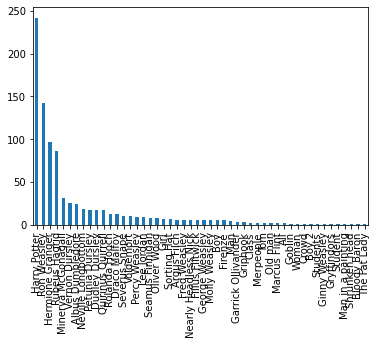

In [5]:
m1["Character Name"].value_counts().plot.bar();

Внутри `plot.bar()` можем указать аргумент `figsize` и скорректировать размер графика:

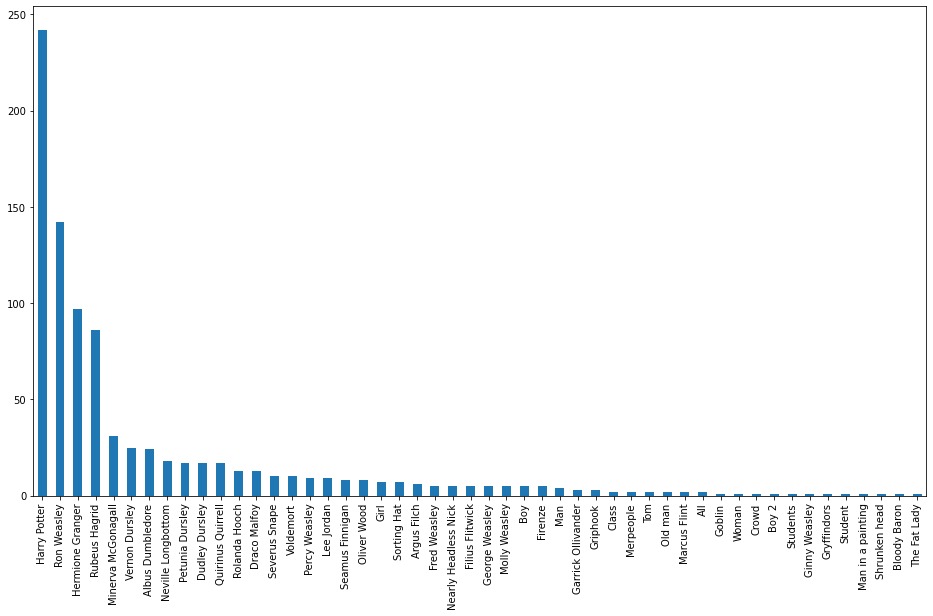

In [6]:
# 16 на 9 дюймов
m1["Character Name"].value_counts().plot.bar(figsize = (16, 9));

График получился довольно понятным, однако обычно если столбцов очень много, соответствующие им категории объединяют в более крупные группы. Давайте проделаем следующую операцию: «схлопнем» всех героев, которые произносят менее 10 реплик в категорию `"Other"`, чтобы вместо множества маленьких столбцов высотой менее 10 на диаграмме был один столбец разумной высоты. 

Для этого необходимо вернуться к результату `.value_counts()`. Сохраним его в переменную `tab`:

In [7]:
tab = m1["Character Name"].value_counts()
tab

Harry Potter            242
Ron Weasley             142
Hermione Granger         97
Rubeus Hagrid            86
Minerva McGonagall       31
Vernon Dursley           25
Albus Dumbledore         24
Neville Longbottom       18
Petunia Dursley          17
Dudley Dursley           17
Quirinus Quirrell        17
Rolanda Hooch            13
Draco Malfoy             13
Severus Snape            10
Voldemort                10
Percy Weasley             9
Lee Jordan                9
Seamus Finnigan           8
Oliver Wood               8
Girl                      7
Sorting Hat               7
Argus Filch               6
Fred Weasley              5
Nearly Headless Nick      5
Filius Flitwick           5
George Weasley            5
Molly Weasley             5
Boy                       5
Firenze                   5
Man                       4
Garrick Ollivander        3
Griphook                  3
Class                     2
Merpeople                 2
Tom                       2
Old man             

Чтобы объединить данные для героев с `"Percy Weasley"` до `"The Fat Lady"` в одну категорию `"Other"`, нужно заменить все эти имена на `"Other"`, а затем сложить частоты этих имён. Чтобы выполнить замену по условию (значение частоты меньше 10), вспомним, что представляет собой `tab`.

Несмотря на то, что `tab` мы называем таблицей частот, с точки зрения `pandas` это не таблица (датафрейм), а отдельный столбец (последовательность или серия `Series`). Структура такого объекта похожа на словарь и массив одновременно. С одной стороны, в `tab` хранятся пары *ключ-значение*  – имена героев и соответствующие им частоты:

In [8]:
# ключи = индексы .index
# значения .values

print(tab.index)
print(tab.values)

Index(['Harry Potter', 'Ron Weasley', 'Hermione Granger', 'Rubeus Hagrid',
       'Minerva McGonagall', 'Vernon Dursley', 'Albus Dumbledore',
       'Neville Longbottom', 'Petunia Dursley', 'Dudley Dursley',
       'Quirinus Quirrell', 'Rolanda Hooch', 'Draco Malfoy', 'Severus Snape',
       'Voldemort', 'Percy Weasley', 'Lee Jordan', 'Seamus Finnigan',
       'Oliver Wood', 'Girl', 'Sorting Hat', 'Argus Filch', 'Fred Weasley',
       'Nearly Headless Nick', 'Filius Flitwick', 'George Weasley',
       'Molly Weasley', 'Boy', 'Firenze', 'Man', 'Garrick Ollivander',
       'Griphook', 'Class', 'Merpeople', 'Tom', 'Old man', 'Marcus Flint',
       'All', 'Goblin', 'Woman', 'Crowd', 'Boy 2', 'Students', 'Ginny Weasley',
       'Gryffindors', 'Student', 'Man in a painting', 'Shrunken head',
       'Bloody Baron', 'The Fat Lady'],
      dtype='object')
[242 142  97  86  31  25  24  18  17  17  17  13  13  10  10   9   9   8
   8   7   7   6   5   5   5   5   5   5   5   4   3   3   2   2   2

С другой стороны, `tab` можно рассматривать как массив, где индексы элементов не числовые, а текстовые. Вспомним, как формулируются условия на массивах и выберем значения меньше 10: 

In [9]:
tab[tab < 10]

Percy Weasley           9
Lee Jordan              9
Seamus Finnigan         8
Oliver Wood             8
Girl                    7
Sorting Hat             7
Argus Filch             6
Fred Weasley            5
Nearly Headless Nick    5
Filius Flitwick         5
George Weasley          5
Molly Weasley           5
Boy                     5
Firenze                 5
Man                     4
Garrick Ollivander      3
Griphook                3
Class                   2
Merpeople               2
Tom                     2
Old man                 2
Marcus Flint            2
All                     2
Goblin                  1
Woman                   1
Crowd                   1
Boy 2                   1
Students                1
Ginny Weasley           1
Gryffindors             1
Student                 1
Man in a painting       1
Shrunken head           1
Bloody Baron            1
The Fat Lady            1
Name: Character Name, dtype: int64

Сохраним имена героев, которые нужно заменить на слово `Other`, в переменную `other`:

In [10]:
# забираем только индексы
other = tab[tab < 10].index
print(other)

Index(['Percy Weasley', 'Lee Jordan', 'Seamus Finnigan', 'Oliver Wood', 'Girl',
       'Sorting Hat', 'Argus Filch', 'Fred Weasley', 'Nearly Headless Nick',
       'Filius Flitwick', 'George Weasley', 'Molly Weasley', 'Boy', 'Firenze',
       'Man', 'Garrick Ollivander', 'Griphook', 'Class', 'Merpeople', 'Tom',
       'Old man', 'Marcus Flint', 'All', 'Goblin', 'Woman', 'Crowd', 'Boy 2',
       'Students', 'Ginny Weasley', 'Gryffindors', 'Student',
       'Man in a painting', 'Shrunken head', 'Bloody Baron', 'The Fat Lady'],
      dtype='object')


Теперь выполним замену в `tab`: если имя (индекс) входит в перечень `other`, вместо него ставим `"Other"`, если нет – оставляем как есть. Для замены воспользуемся методом `.rename()`. Раньше мы использовали его для переименования столбцов в датафрейме и в аргумент `columns` вписывали словарь с парой *старое название-новое название*, но сейчас мы имеем дело с одним единственным столбцом, где переименовать можно только индексы – названия строк.

Поместим в `.rename()` lambda-функцию, которая принимает на вход строку с именем `x` и:

* если `x` входит в `other`, возвращает `"Other"`;
* если иначе, возращает просто `x`.

In [11]:
# inplace = True – сохраняем изменения в tab

tab.rename(lambda x: "Other" if x in other else x, inplace = True)
tab

Harry Potter          242
Ron Weasley           142
Hermione Granger       97
Rubeus Hagrid          86
Minerva McGonagall     31
Vernon Dursley         25
Albus Dumbledore       24
Neville Longbottom     18
Petunia Dursley        17
Dudley Dursley         17
Quirinus Quirrell      17
Rolanda Hooch          13
Draco Malfoy           13
Severus Snape          10
Voldemort              10
Other                   9
Other                   9
Other                   8
Other                   8
Other                   7
Other                   7
Other                   6
Other                   5
Other                   5
Other                   5
Other                   5
Other                   5
Other                   5
Other                   5
Other                   4
Other                   3
Other                   3
Other                   2
Other                   2
Other                   2
Other                   2
Other                   2
Other                   2
Other       

Итак, замена сработала, теперь надо сложить все частоты для `"Other"`, чтобы получить одну пару *название-значение*. Самый простой способ – выполнить группировку, а затем применить метод `.sum()`. Когда мы применяли группировку к таблицам, в `.groupby()` указывали название столбца-основания группировки. Здесь мы уже внутри столбца, поэтому сгруппировать значения можно только по их индексам. Так как индексы здесь простые, не многоуровневые, это `level = 0`:

In [12]:
tab.groupby(level = 0).sum()

Albus Dumbledore       24
Draco Malfoy           13
Dudley Dursley         17
Harry Potter          242
Hermione Granger       97
Minerva McGonagall     31
Neville Longbottom     18
Other                 123
Petunia Dursley        17
Quirinus Quirrell      17
Rolanda Hooch          13
Ron Weasley           142
Rubeus Hagrid          86
Severus Snape          10
Vernon Dursley         25
Voldemort              10
Name: Character Name, dtype: int64

Отлично, теперь у нас одна категория `Other` и соответствующая ей частота 123. Метод `.groupby()` автоматически выполняет сортировку групп по алфавиту. Чтобы вернуть сортировку по убыванию частоты, применим метод `.sort_values()`:

In [13]:
# выключаем возрастание через ascending = False

tab2 = tab.groupby(level = 0).sum().sort_values(ascending = False)
tab2

Harry Potter          242
Ron Weasley           142
Other                 123
Hermione Granger       97
Rubeus Hagrid          86
Minerva McGonagall     31
Vernon Dursley         25
Albus Dumbledore       24
Neville Longbottom     18
Dudley Dursley         17
Petunia Dursley        17
Quirinus Quirrell      17
Draco Malfoy           13
Rolanda Hooch          13
Severus Snape          10
Voldemort              10
Name: Character Name, dtype: int64

**Дополнение.** Если не совсем понятно, почему выше `level = 0`, и когда он может быть не 0, вспомните прошлое занятие и сюжет про мультииндексы. Если мы сгруппируем строки в `m1` сначала по факультету, потом – по имени героя, а затем вычислим количество реплик, получится столбец с частотами, где индексы представляют собой пары *факультет-имя*. Первые элементы в парах – названия факультетов – это значения уровня 0, а вторые – имена героев – значения уровня 1:

In [14]:
# House – level = 0
# Character Name – level = 1

hc = m1.groupby(["House", "Character Name"])["Dialogue"].count()
hc

House       Character Name      
Gryffindor  Albus Dumbledore         24
            Fred Weasley              5
            George Weasley            5
            Ginny Weasley             1
            Harry Potter            242
            Hermione Granger         97
            Lee Jordan                9
            Minerva McGonagall       31
            Molly Weasley             5
            Nearly Headless Nick      5
            Neville Longbottom       18
            Oliver Wood               8
            Percy Weasley             9
            Ron Weasley             142
            Rubeus Hagrid            86
            Seamus Finnigan           8
Ravenclaw   Filius Flitwick           5
            Garrick Ollivander        3
            Quirinus Quirrell        17
Slytherin   Bloody Baron              1
            Draco Malfoy             13
            Marcus Flint              2
            Severus Snape            10
            Voldemort                10
Name: D

Замена значений менее 10 на `Other` здесь работает как и раньше, однако для получения имён вместо полных индексов (факультет + имя) придётся выбирать нужный уровень:

In [15]:
# хорошо, но не то, факультеты мы заменять не хотим
hc[hc < 10].index

MultiIndex([('Gryffindor',         'Fred Weasley'),
            ('Gryffindor',       'George Weasley'),
            ('Gryffindor',        'Ginny Weasley'),
            ('Gryffindor',           'Lee Jordan'),
            ('Gryffindor',        'Molly Weasley'),
            ('Gryffindor', 'Nearly Headless Nick'),
            ('Gryffindor',          'Oliver Wood'),
            ('Gryffindor',        'Percy Weasley'),
            ('Gryffindor',      'Seamus Finnigan'),
            ( 'Ravenclaw',      'Filius Flitwick'),
            ( 'Ravenclaw',   'Garrick Ollivander'),
            ( 'Slytherin',         'Bloody Baron'),
            ( 'Slytherin',         'Marcus Flint')],
           names=['House', 'Character Name'])

In [16]:
# вот теперь то, только значения второго уровня
# get_level_values(level = 1)

to_replace = hc[hc < 10].index.get_level_values(level = 1)
to_replace

Index(['Fred Weasley', 'George Weasley', 'Ginny Weasley', 'Lee Jordan',
       'Molly Weasley', 'Nearly Headless Nick', 'Oliver Wood', 'Percy Weasley',
       'Seamus Finnigan', 'Filius Flitwick', 'Garrick Ollivander',
       'Bloody Baron', 'Marcus Flint'],
      dtype='object', name='Character Name')

In [17]:
# заменяем имена (на уровне level = 1)
# группируем по имени (на уровне level = 1)
# суммируем и сортируем

hc.rename(lambda x: "Other" if x in to_replace else x, level = 1, inplace = True)
hc.groupby(level = 1).sum().sort_values()

Character Name
Severus Snape          10
Voldemort              10
Draco Malfoy           13
Quirinus Quirrell      17
Neville Longbottom     18
Albus Dumbledore       24
Minerva McGonagall     31
Other                  66
Rubeus Hagrid          86
Hermione Granger       97
Ron Weasley           142
Harry Potter          242
Name: Dialogue, dtype: int64

P.S. Если группировать по факультету (здесь после перехода к уровню имён факультеты исчезли), результаты отличаются от того, что получилось у нас в `tab2`, потому что не для всех героев определены факультеты. Так, в `hc` нет строчек для Дурслей (`Vernon Dursley`, `Dudley Dursley`, `Petunia Dursley`) и строчки для мадам Трюк (`Rolanda Hooch`), потому что Дурсли – маглы, а подробная информация о преподавателе полётов отсутствует.

**Конец дополнения.**

Применим к обновлённой таблице метод `.plot.bar()` и построим столбиковую диаграмму:

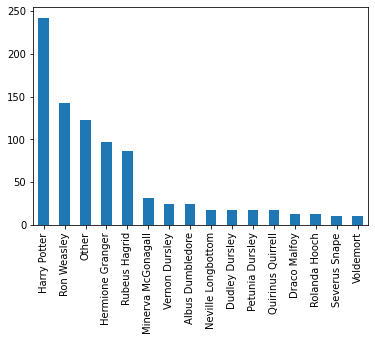

In [18]:
tab2.plot.bar();

Применим к обновлённой таблице метод `.plot.pie()` и построим круговую диаграмму:

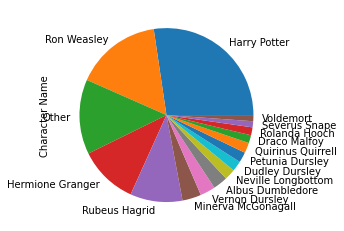

In [19]:
tab2.plot.pie();

Первый график – вполне удачный, а вот второй лучше никому не показывать :) Если задача – показать распределение количества реплик по героям, столбиковая диаграмма с ней справляется (даже если нужны проценты, до замены в `.value_counts()` можно поставить `normalize = True`, и тогда мы получим не абсолютные частоты, а доли, которые легко домножить на 100 и вынести на график). 

Но если из каких-то соображений обязательно нужна круговая диаграмма, имеет смысл расширить категорию `Other` или каким-то ещё образом сгруппировать героев, чтобы уменьшить число секторов круга. Потому что сейчас для 16 категорий даже уникальных цветов не хватает, в какой-то момент они начали повторяться – стандартная палитра `tab10` включает 10 цветов, принятых в Tableau.

### Столбиковая диаграмма c `matplotlib`

Чтобы доработать столбиковую диаграмму, полученную выше, построим её с помощью графической библиотеки `matplotlib` (в `pandas` представлен ограниченный функционал этой библиотеки). Импортируем модуль `pyplot` с сокращённым названием `plt`:

In [20]:
from matplotlib import pyplot as plt

Для создания нового графика воспользуемся функцией `subplots()`:

(<Figure size 432x288 with 1 Axes>, <AxesSubplot:>)

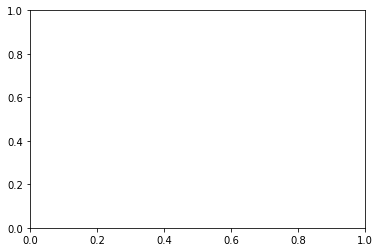

In [21]:
plt.subplots()

Эта функция создаёт два объекта:

* само изображение (графический объект `Figure` некоторого размера);
* канва с осями (контейнер `Axes`), по умолчанию с двумя осями от 0 до 1.

При работе с графиками в `matplotlib` мы резервируем место под картинку соответствующего размера, а затем проводим различные манипуляции с `Axes`, чтобы внутри этой канвы построить график, настроить подписи к нему, засечки на осях и прочее. Соответственно, к `Axes` мы будем применять различные методы, а по завершении работы сможем выгрузить объект `Figure` в файл PNG, JPEG или PDF. Вообще функция `subplots()`, как следует из её названия, может использоваться для построения сразу нескольких графиков (подграфиков, если точнее), но у нас пока будет один.

Сохраним первый объект в переменную `fig`, а второй – в переменную `ax` (это распространённые названия, хотя необязательные), заодно изменим размер картинки и её разрешение:

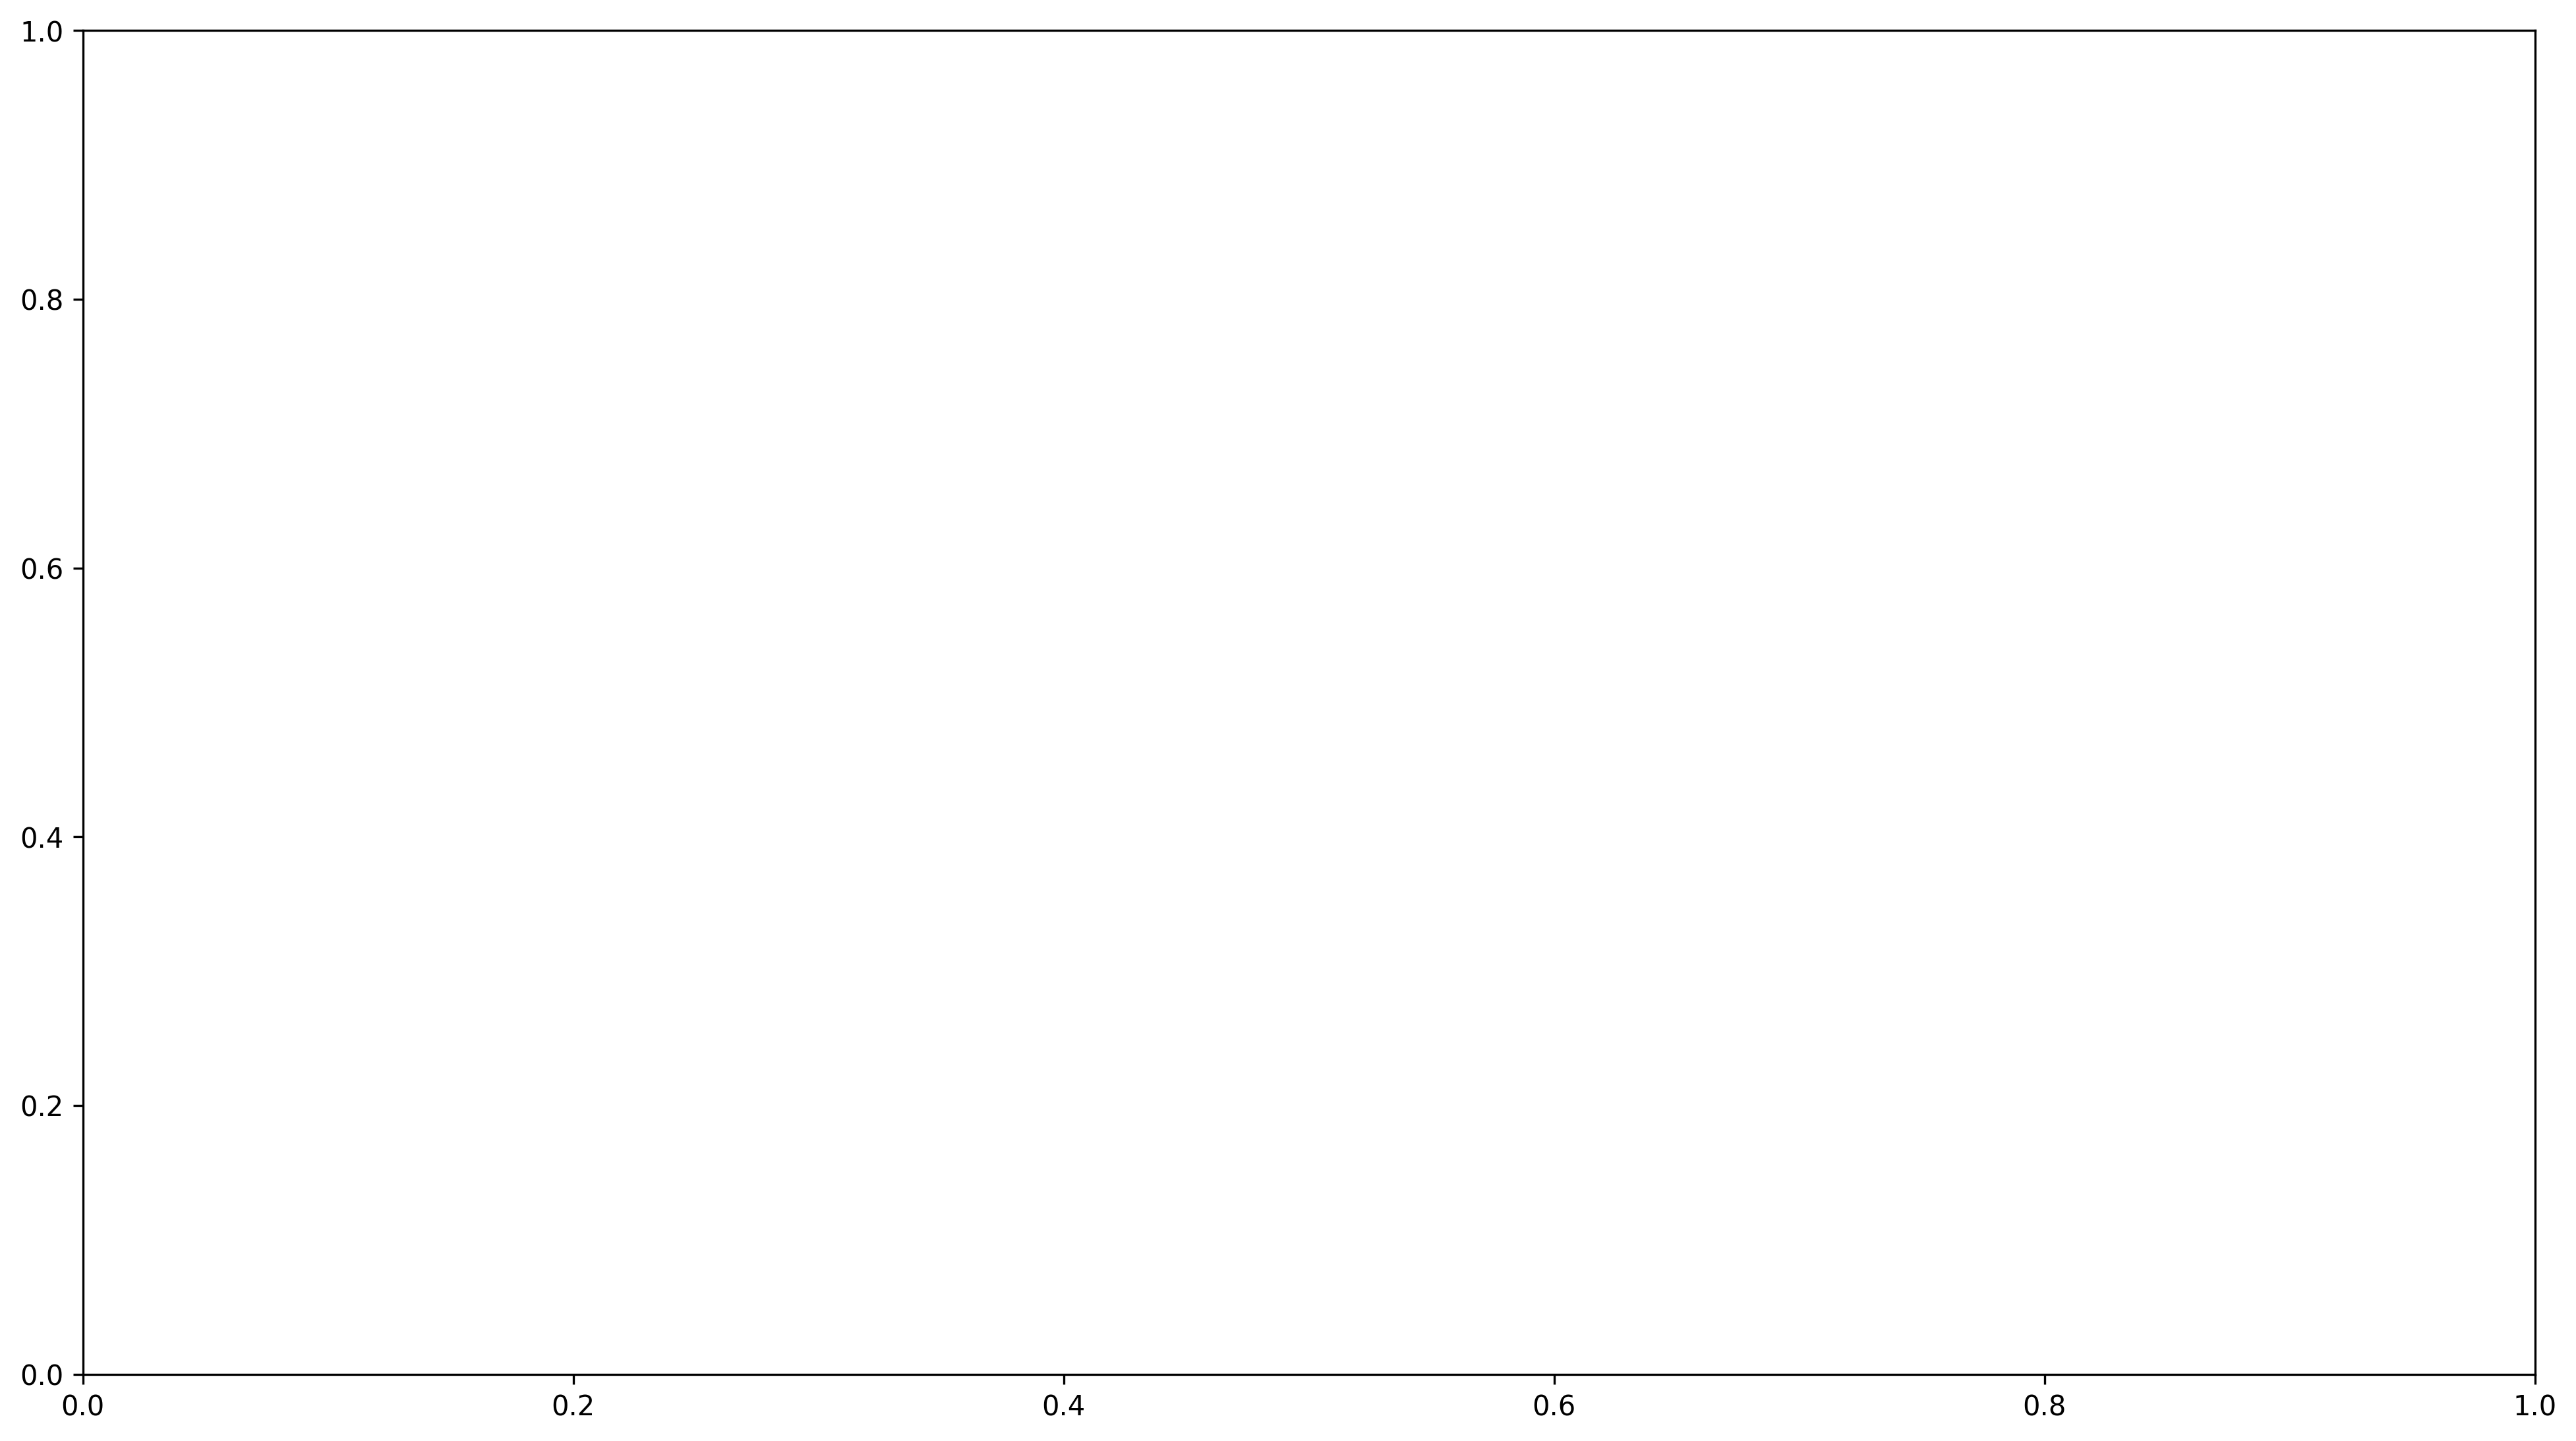

In [22]:
# размер 16 на 9 дюймов
# разрешение 300 точек на дюйм (dots per inch)

fig, ax = plt.subplots(figsize = (16, 9), dpi = 300)

Применим к канве с осями `ax` метод `.bar()`, тем самым добавив туда столбиковую диаграмму:

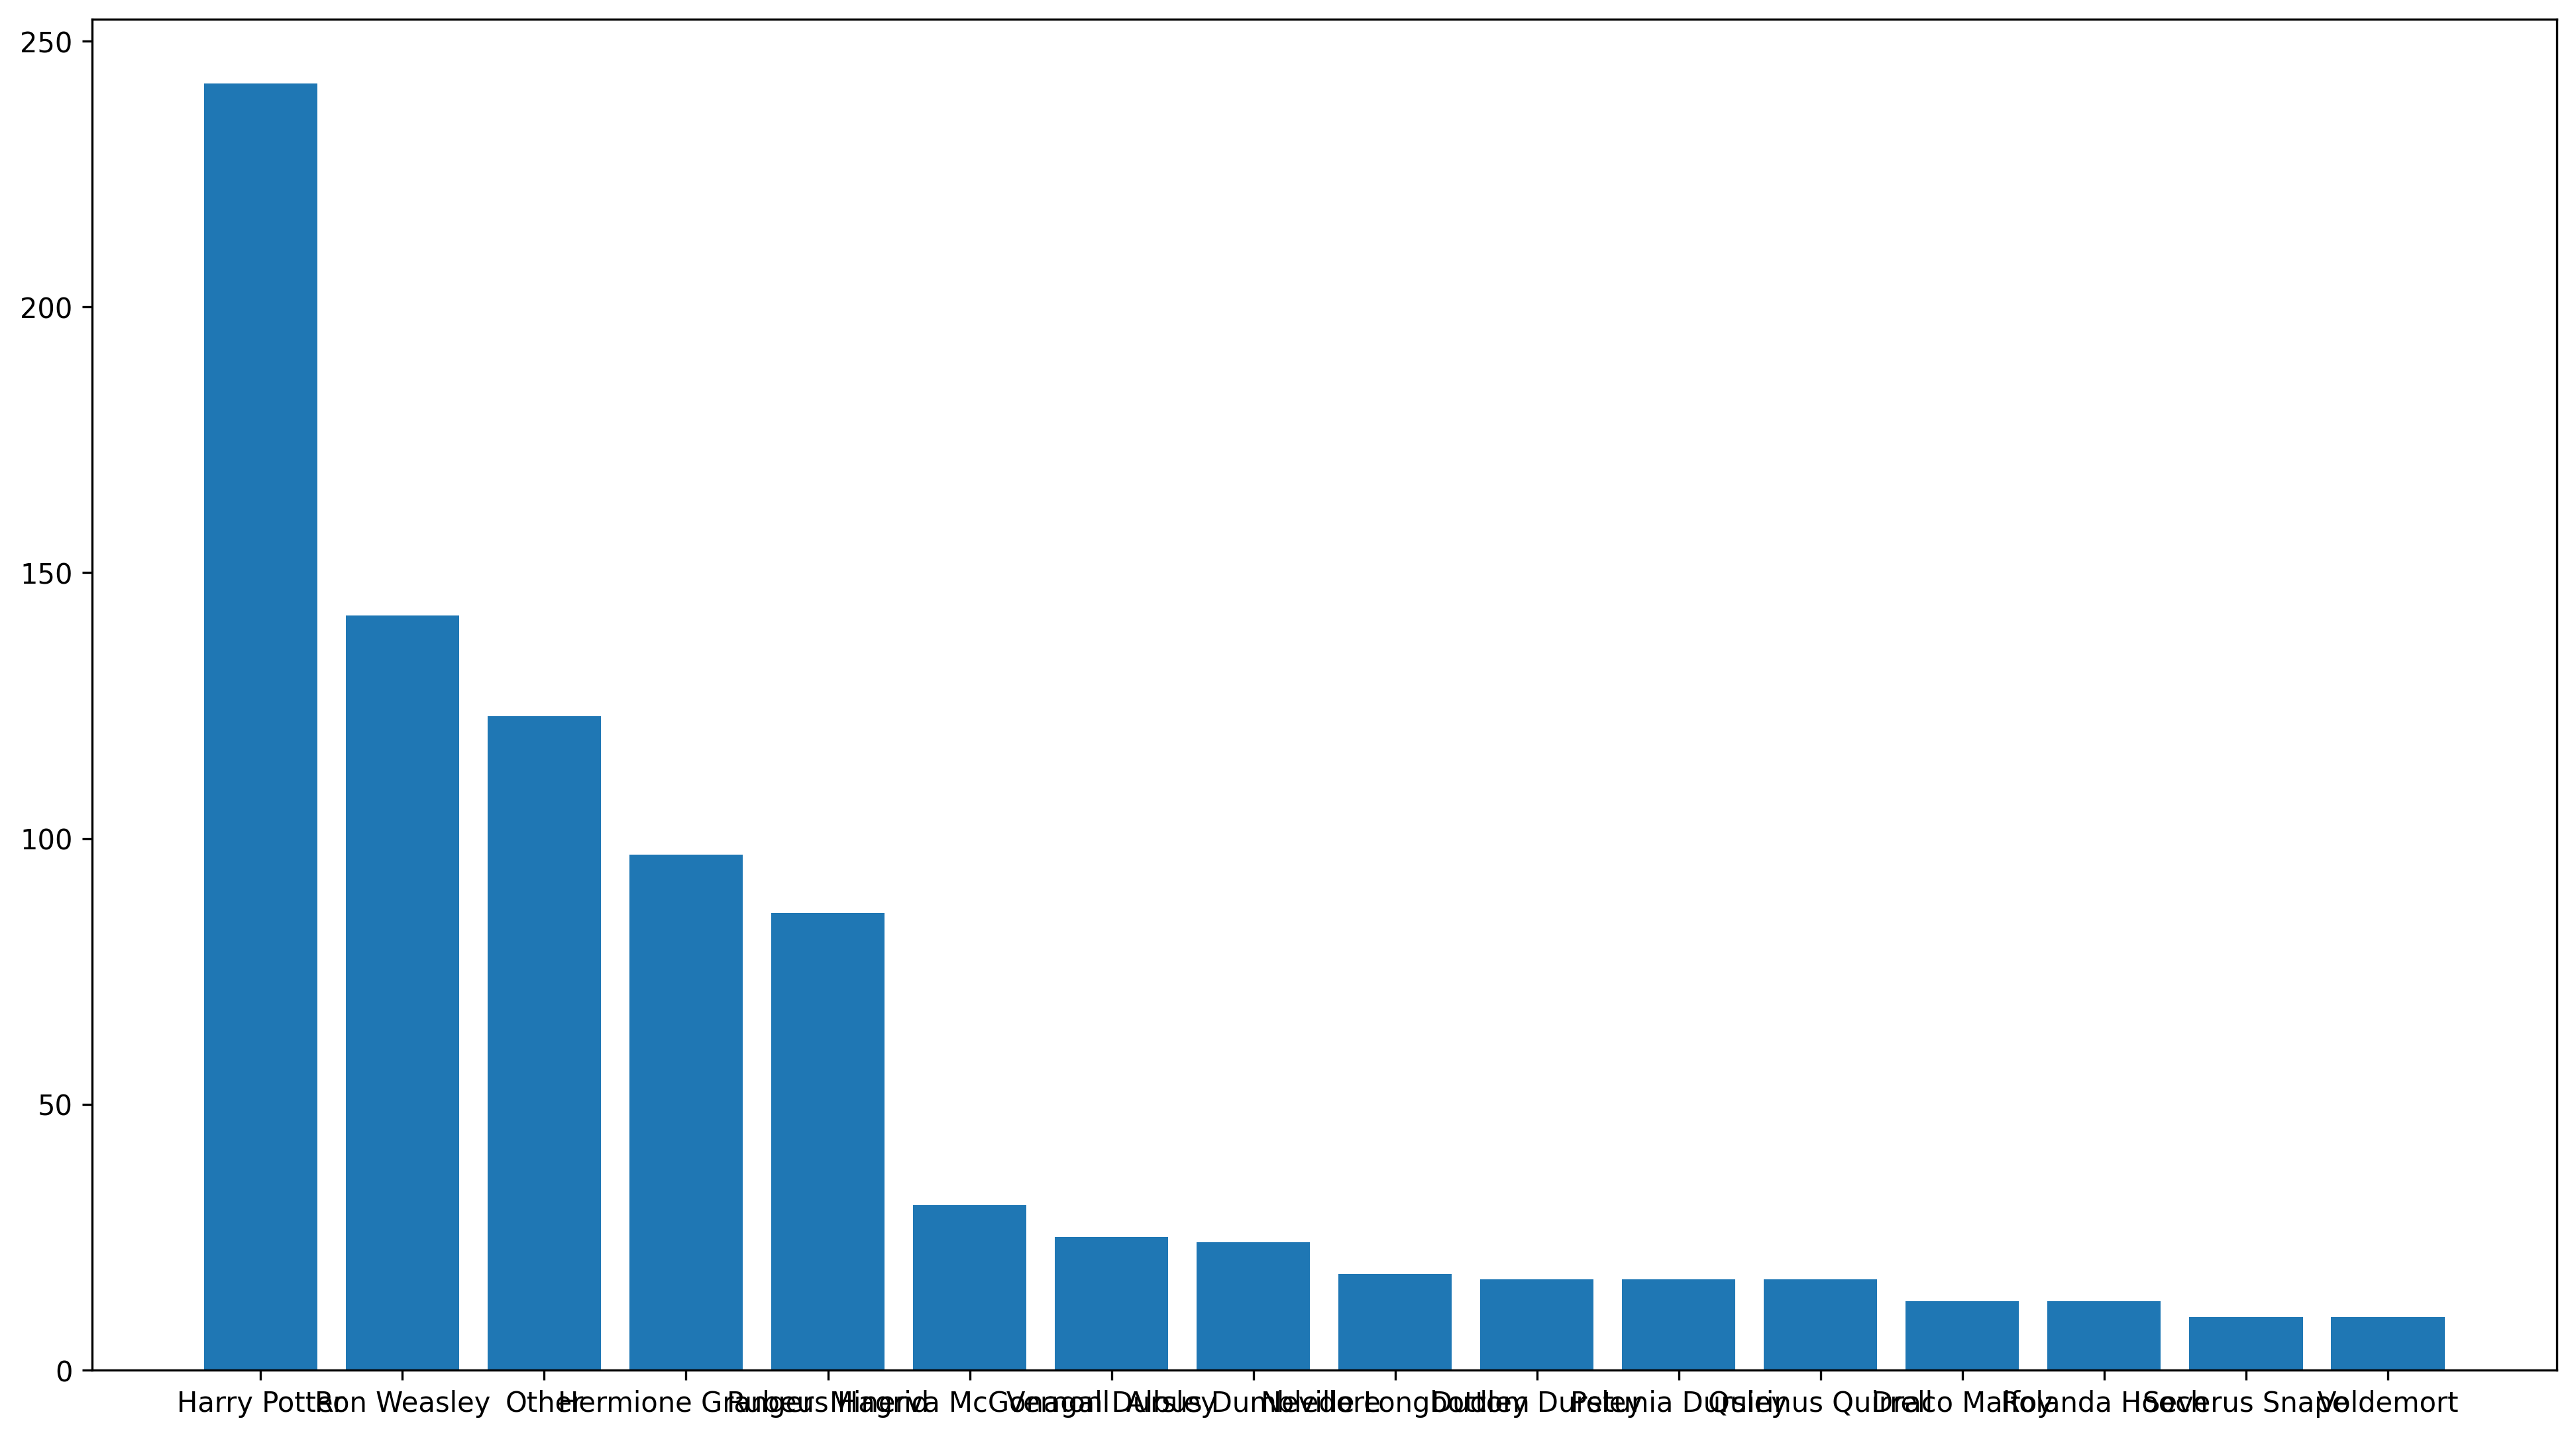

In [23]:
fig, ax = plt.subplots(figsize = (16, 9), dpi = 300)

# по оси X – имена героев (индексы из tab2)
# по оси Y – частоты (значения из tab2)

ax.bar(tab2.index, tab2.values);

Для настройки различных параметров графика мы будем применять методы к объекту `ax`. Сама картинка `fig` понадобится нам в самом конце – когда мы захотим выгрузить её в файл.

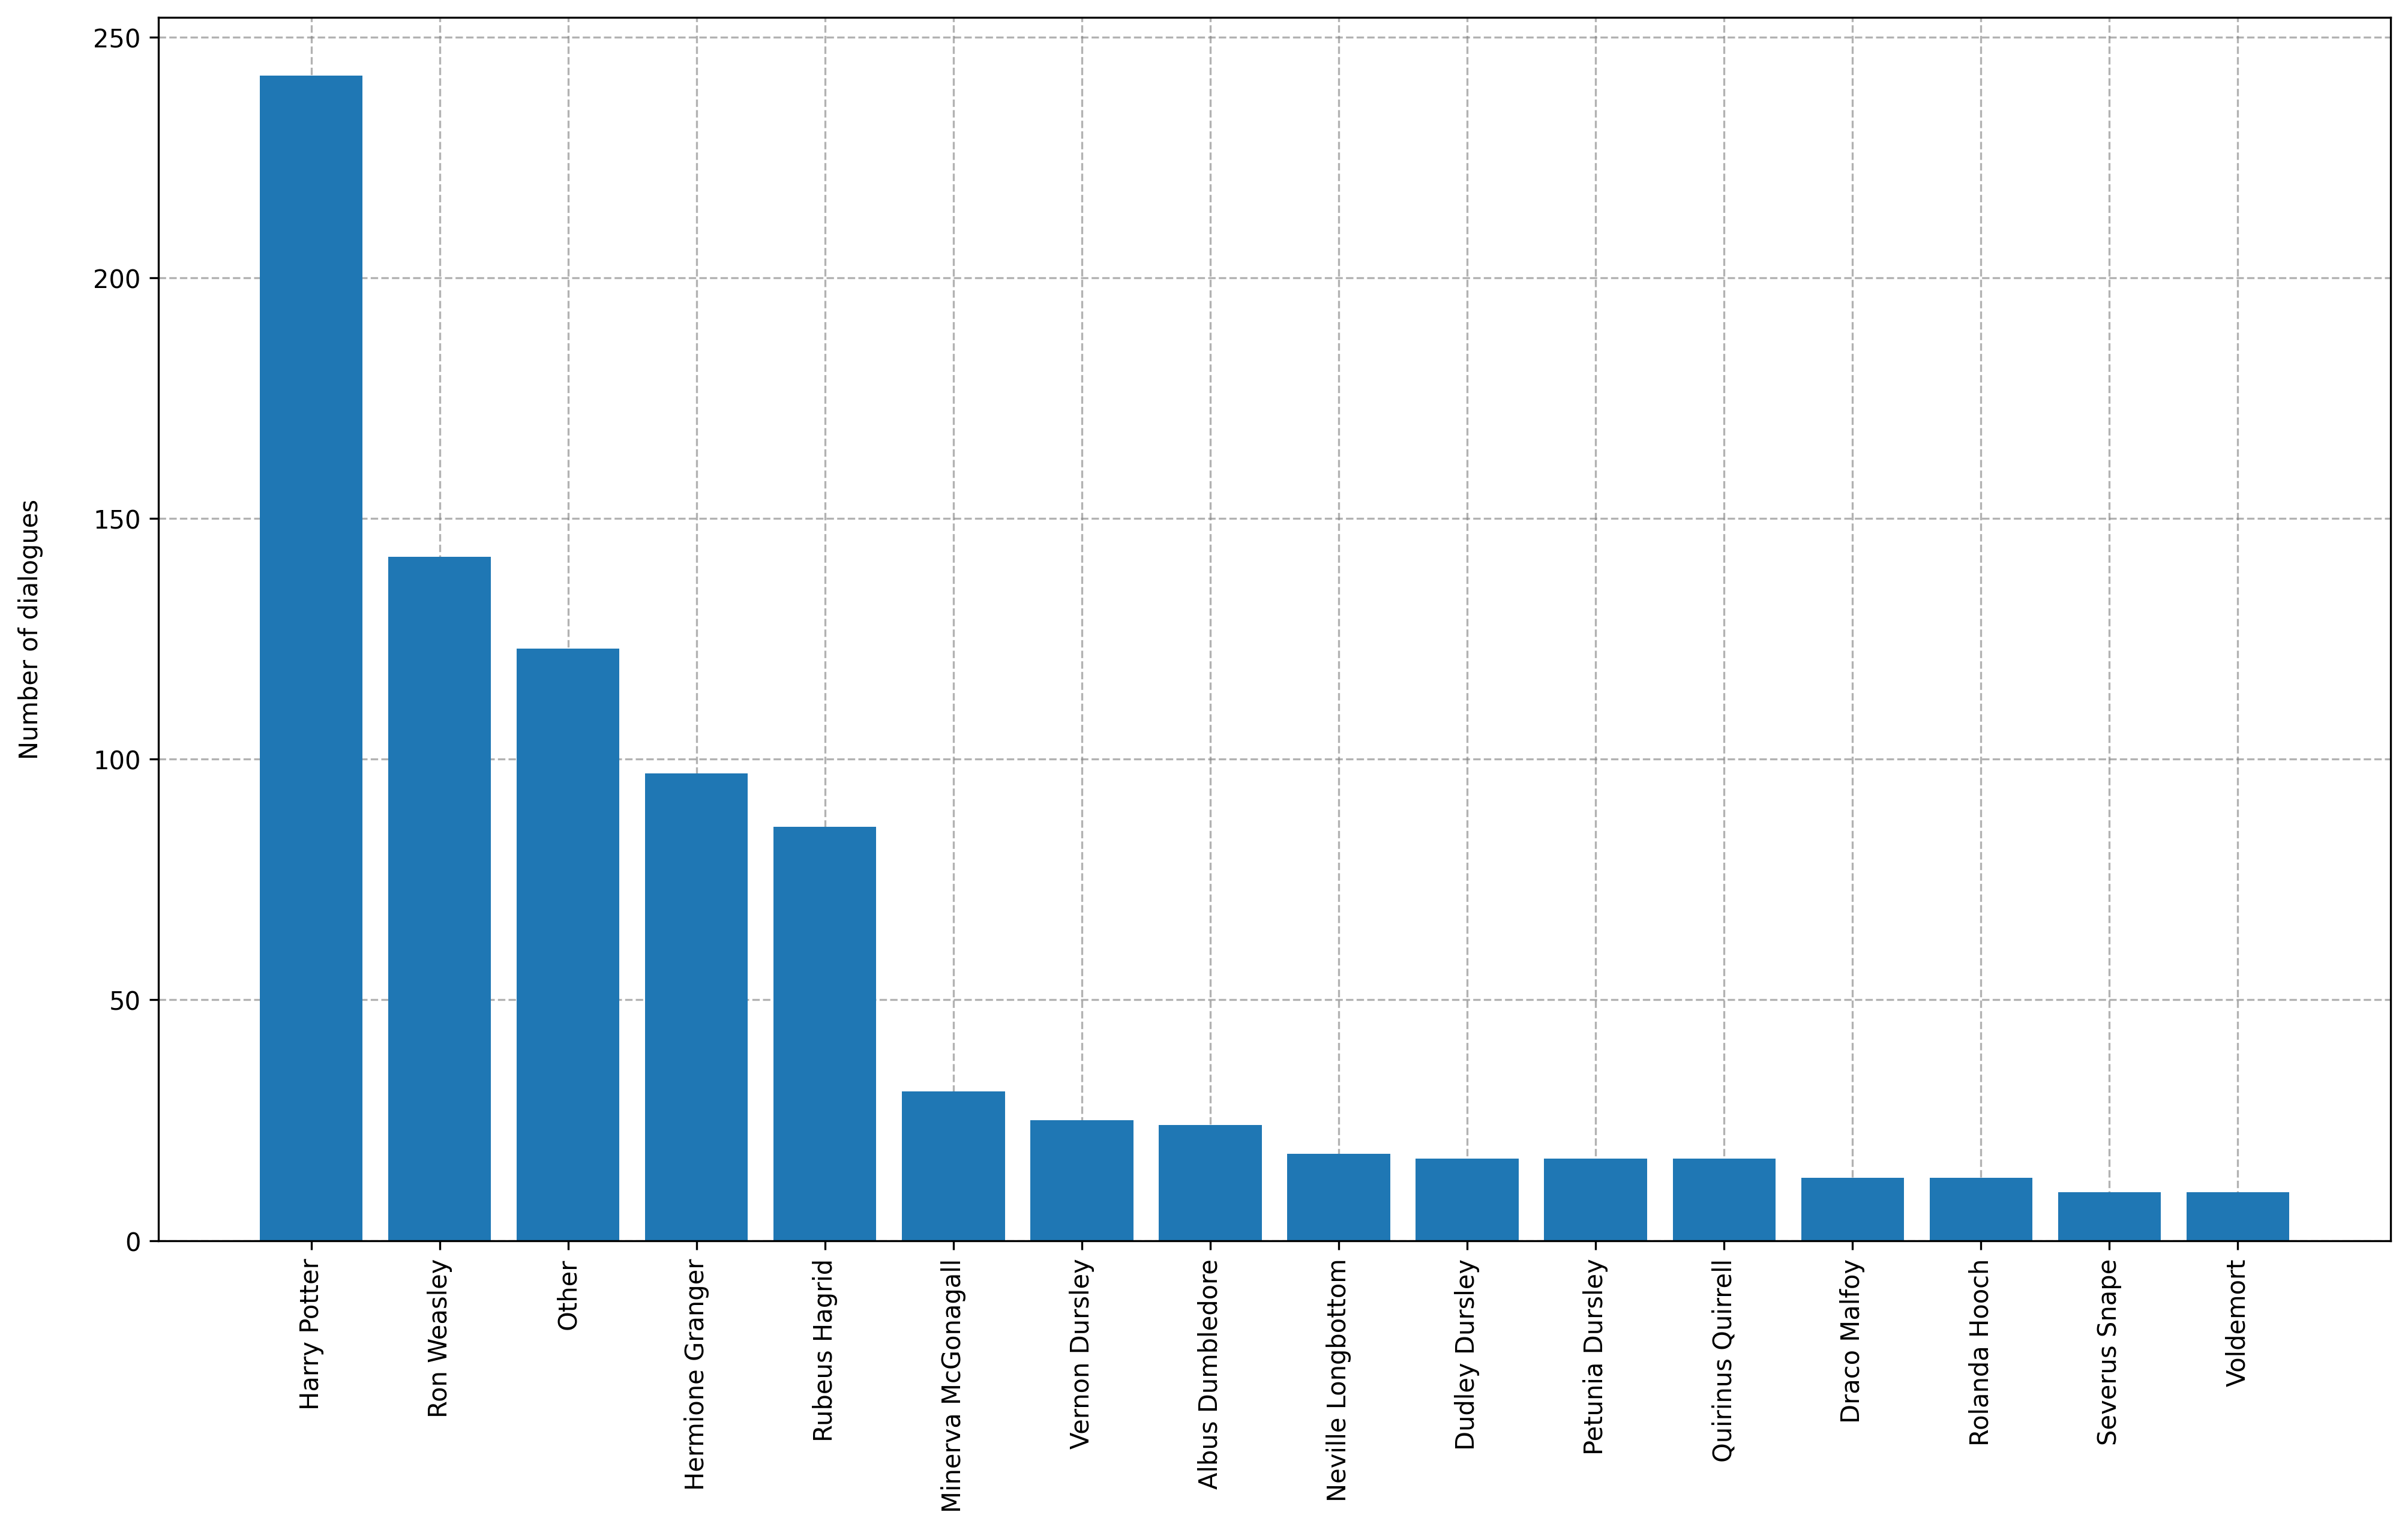

In [24]:
fig, ax = plt.subplots(figsize = (16, 9), dpi = 300)

ax.bar(tab2.index, tab2.values);

# добавляем координатную сетку 
# серый цвет, тип пунктирный, прозрачность 40%

ax.grid(color = 'grey', 
        alpha = 0.6, 
        linestyle = 'dashed');

# ставим сетку под графиком, 
# чтобы не перечеркивала столбцы

ax.set_axisbelow(True)

# добавляем подпись к оси Y
# с отступом от оси 20 пунктов

ax.set_ylabel("Number of dialogues", 
              labelpad = 20);

# подписи по оси X с поворотом на 90 градусов

ax.tick_params(axis = 'x', 
               labelrotation = 90)

Поработаем с цветами столбцов. Если один цвет для всех столбцов нас устраивает, всё просто – в аргумент `color` в `.bar()` вписываем название нового цвета:

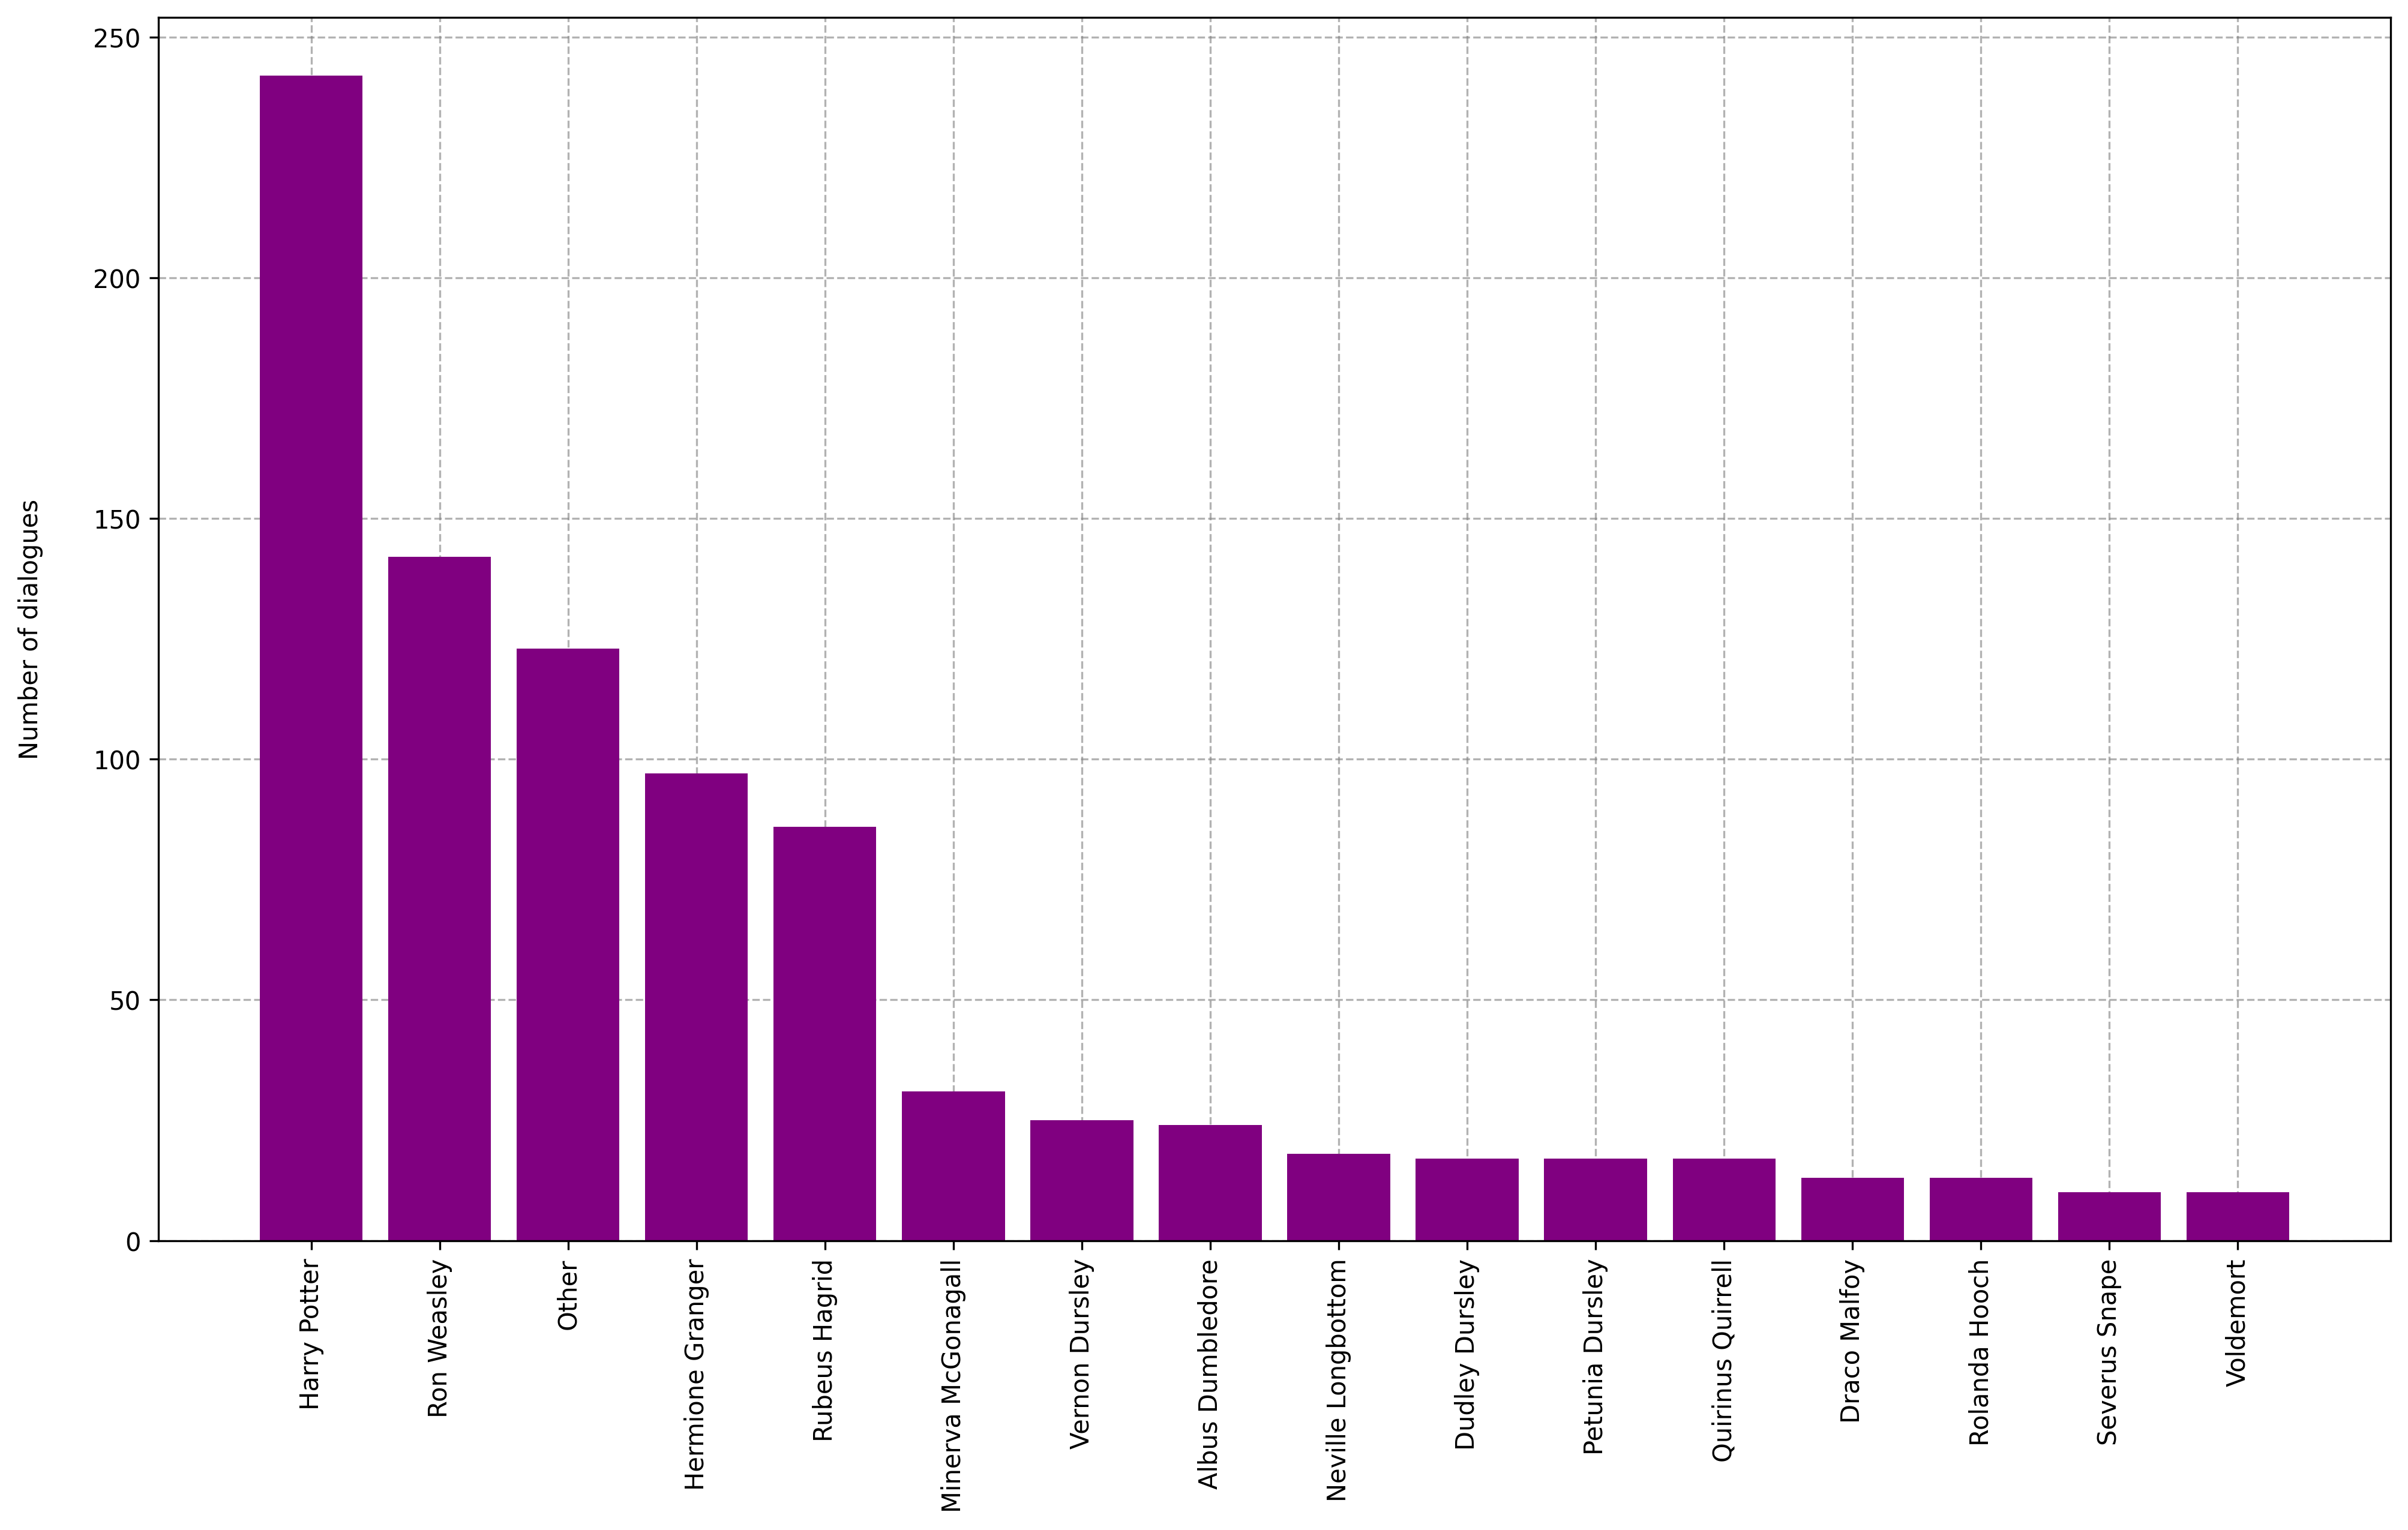

In [25]:
fig, ax = plt.subplots(figsize = (16, 9), dpi = 300)

# color

ax.bar(tab2.index, tab2.values, color = "purple");

ax.grid(color = 'grey', 
        alpha = 0.6, 
        linestyle = 'dashed');

ax.set_axisbelow(True)

ax.set_ylabel("Number of dialogues", 
              labelpad = 20);

ax.tick_params(axis = 'x', 
               labelrotation = 90)

Если мы за каждым столбцом хотим закрепить свой цвет, в `color` придётся записать список из 16 названий. Однако, если названий в списке будет меньше, ошибки не будет, цвета просто будут чередоваться:

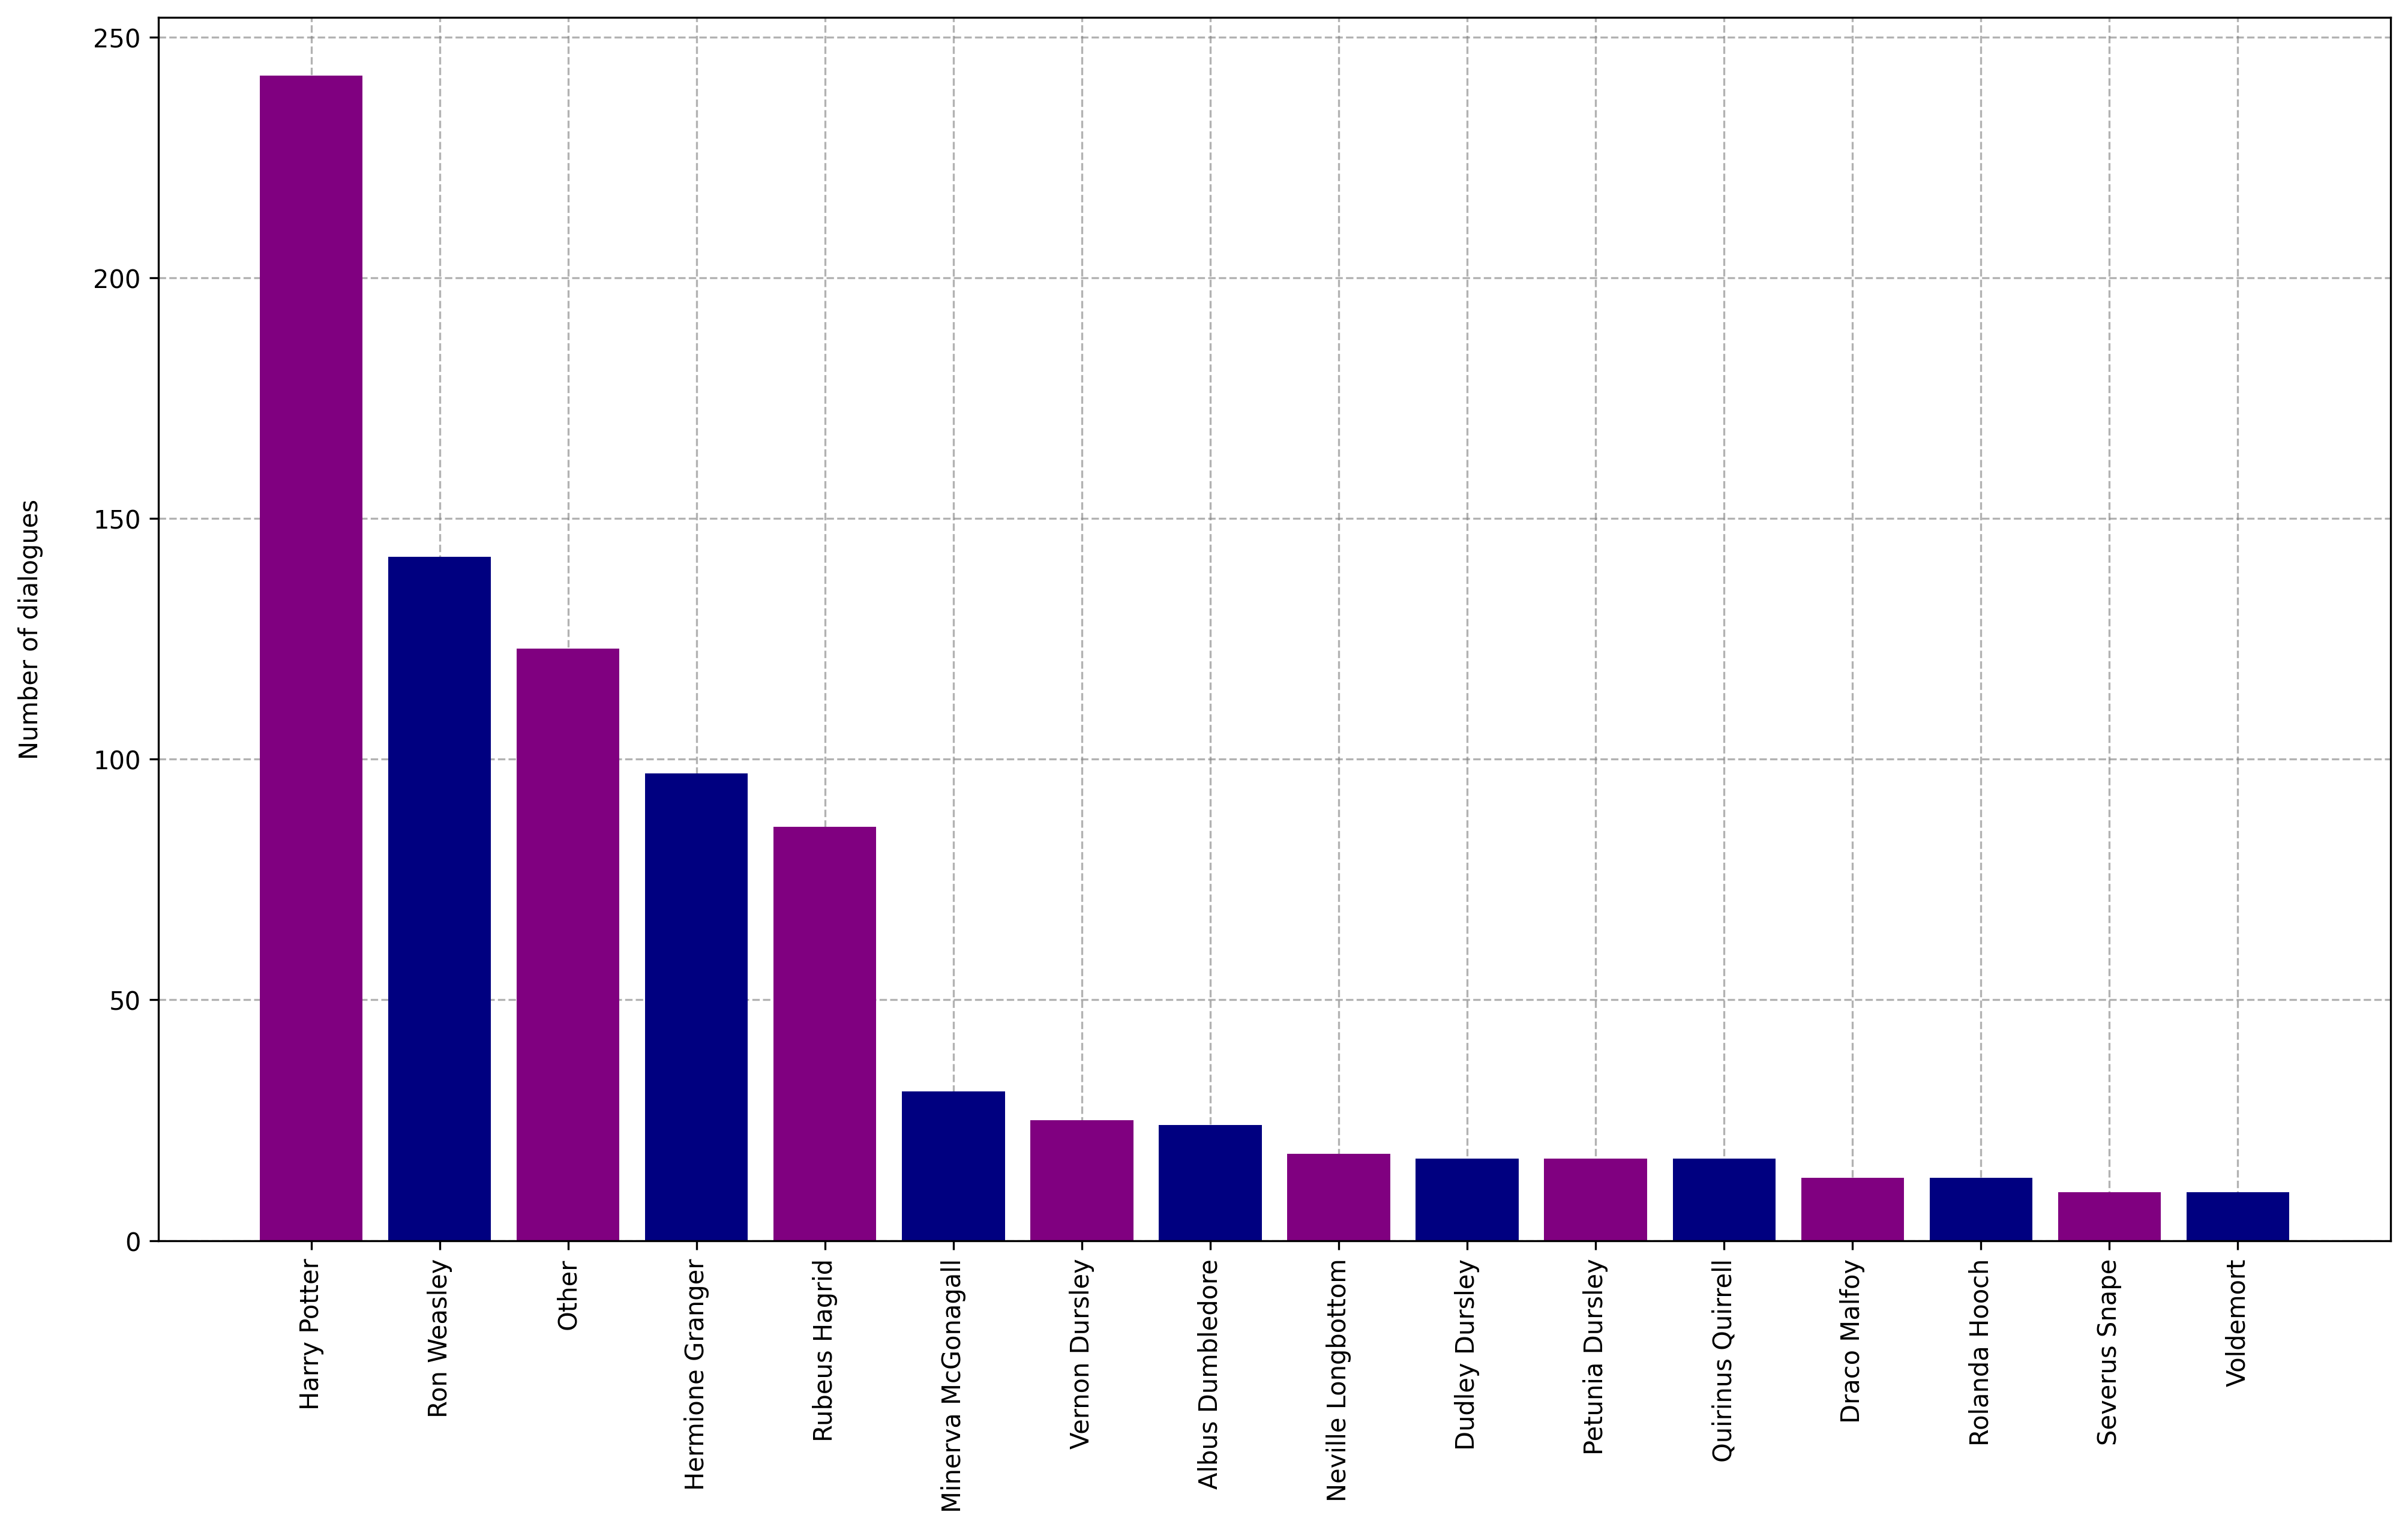

In [26]:
fig, ax = plt.subplots(figsize = (16, 9), dpi = 300)

ax.bar(tab2.index, tab2.values, color = ["purple", "navy"]);

ax.grid(color = 'grey', 
        alpha = 0.6, 
        linestyle = 'dashed');

ax.set_axisbelow(True)

ax.set_ylabel("Number of dialogues", 
              labelpad = 20);

ax.tick_params(axis = 'x', 
               labelrotation = 90)

В заключение создадим свой список цветов, где сначала 5 раз повторяется название `purple`, а затем 11 раз – название `navy`:

In [27]:
my_colors = ["purple"] * 5 + ["navy"] * 11
print(my_colors)

['purple', 'purple', 'purple', 'purple', 'purple', 'navy', 'navy', 'navy', 'navy', 'navy', 'navy', 'navy', 'navy', 'navy', 'navy', 'navy']


Подставим список цветов в `color` и экспортируем график в файл `hp_bar.png`:

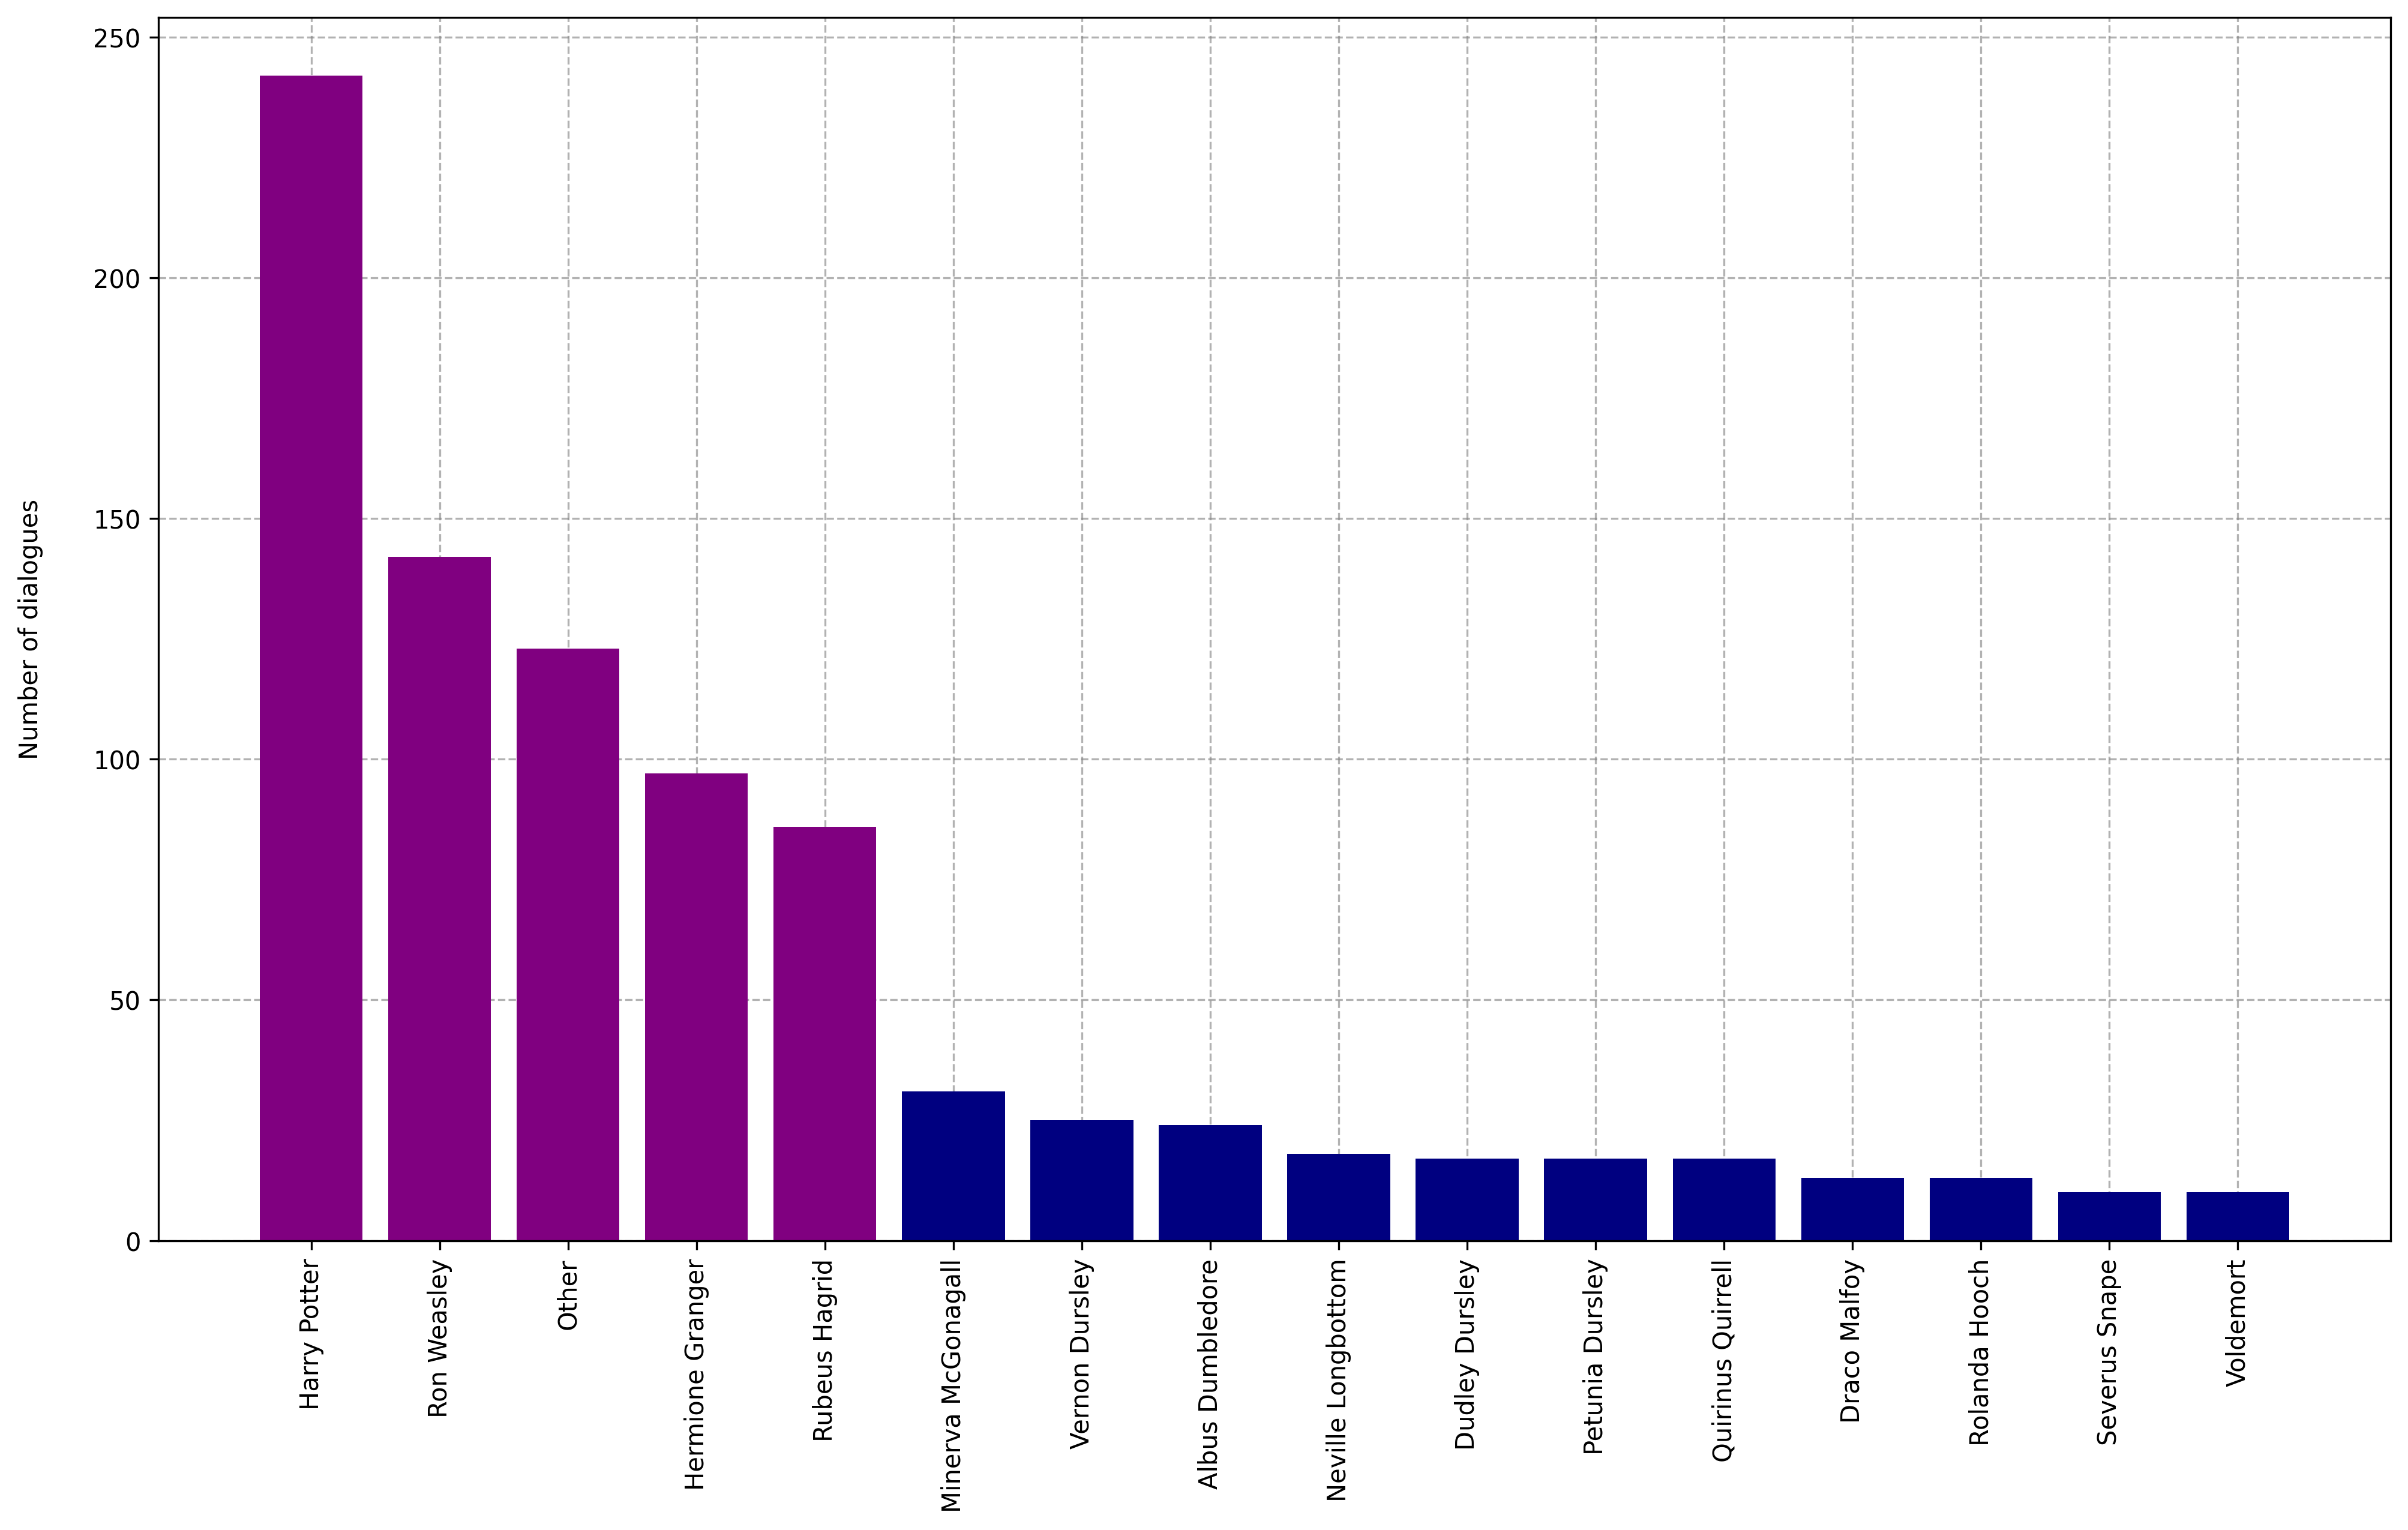

In [28]:
fig, ax = plt.subplots(figsize = (16, 9), dpi = 300)

ax.bar(tab2.index, tab2.values, color = my_colors);

ax.grid(color = 'grey', 
        alpha = 0.6, 
        linestyle = 'dashed');

ax.set_axisbelow(True)

ax.set_ylabel("Number of dialogues", 
              labelpad = 20);

ax.tick_params(axis = 'x', 
               labelrotation = 90)

# рядом с текущим ipynb-файлом должен появиться
# файл hp_bar.png

fig.savefig("hp_bar.png")

### Круговая и кольцевая диаграмма c `matplotlib`



Ранее мы убедились, что круговую диаграмму для распределения цитат по героям лучше не строить без предварительного укрупнения категорий. Поэтому построим круговую диаграмму, позволяющую сравнить бюджеты фильмов относительно друг друга. Обычно круговые диаграммы строят для качественных данных (процент разных ответов на вопросы и подобное), но для сравнения чисел друг с другом их тоже можно использовать. 

Бюджет фильмов в `df` записан в виде строк с `$` и `,`, а не в виде чисел:

In [29]:
df["Budget"].head()

0    $125,000,000 
1    $125,000,000 
2    $125,000,000 
3    $125,000,000 
4    $125,000,000 
Name: Budget, dtype: object

Применим ко всем значениям в столбце функцию, которая выберет все символы в строке, кроме первого (это `$`), а затем заменит `,` на пустую строку:

In [30]:
# все символы, начиная со второго – x[1:]
# замена – replace(",", "")
# не забываем изменить тип столбца на integer

df["BudgetNum"] = df["Budget"].apply(lambda x: x[1:].replace(",", "")).astype(int)
df["BudgetNum"].head()

0    125000000
1    125000000
2    125000000
3    125000000
4    125000000
Name: BudgetNum, dtype: int64

Так как в `df` одна строка – это одна реплика героя, а не фильм, в столбце `BudgetNum` полно дубликатов. Запросим уникальные значения:

In [31]:
df["BudgetNum"].unique()

array([125000000, 200000000, 100000000, 130000000, 150000000, 250000000])

Фильмов о Гарри Поттере должно быть 8, а уникальных значений бюджета оказалось 6. Значит, у каких-то двух фильмов бюджет оказался одинаковым. Чтобы получить соответствия между фильмом и бюджетом и при этом избежать повторений, применим группировку:

In [32]:
# группируем по названию фильма Movie Title
# выводим описательные статистики для BudgetNum

df.groupby("Movie Title")["BudgetNum"].describe()

,count,mean,std,min,25%,50%,75%,max
Movie Title,,,,,,,,
Harry Potter and the Chamber of Secrets,986.0,100000000.0,0.0,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0
Harry Potter and the Deathly Hallows Part 1,1012.0,200000000.0,0.0,200000000.0,200000000.0,200000000.0,200000000.0,200000000.0
Harry Potter and the Deathly Hallows Part 2,712.0,250000000.0,0.0,250000000.0,250000000.0,250000000.0,250000000.0,250000000.0
Harry Potter and the Goblet of Fire,741.0,150000000.0,0.0,150000000.0,150000000.0,150000000.0,150000000.0,150000000.0
Harry Potter and the Half-Blood Prince,1070.0,250000000.0,0.0,250000000.0,250000000.0,250000000.0,250000000.0,250000000.0
Harry Potter and the Order of the Phoenix,1157.0,150000000.0,0.0,150000000.0,150000000.0,150000000.0,150000000.0,150000000.0
Harry Potter and the Philosopher's Stone,885.0,125000000.0,0.0,125000000.0,125000000.0,125000000.0,125000000.0,125000000.0
Harry Potter and the Prisoner of Azkaban,881.0,130000000.0,0.0,130000000.0,130000000.0,130000000.0,130000000.0,130000000.0


Так как бюджет для каждого фильма – одно число, неудивительно, что среднее, медиана, квартили, минимум и максимум по каждому фильму совпадают (а стандартное отклонение при этом 0). По-хорошему, при выборе строк, соответствующих каждому фильму, нам достаточно забрать только первое значение из столбца `BudgetNum`. Применим к результату группировки метод `.first()`:

In [33]:
mg = df.groupby("Movie Title")["BudgetNum"].first()
mg

Movie Title
Harry Potter and the Chamber of Secrets        100000000
Harry Potter and the Deathly Hallows Part 1    200000000
Harry Potter and the Deathly Hallows Part 2    250000000
Harry Potter and the Goblet of Fire            150000000
Harry Potter and the Half-Blood Prince         250000000
Harry Potter and the Order of the Phoenix      150000000
Harry Potter and the Philosopher's Stone       125000000
Harry Potter and the Prisoner of Azkaban       130000000
Name: BudgetNum, dtype: int64

Теперь всё готово к построению круговой диаграммы. Начнём с простого:

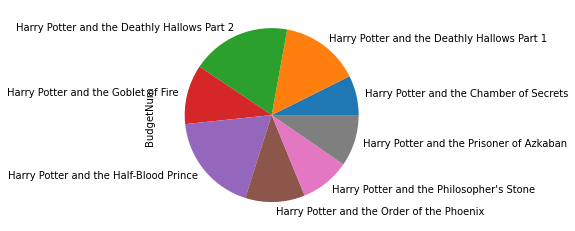

In [34]:
mg.plot.pie();

Чтобы построить график с помощью `matplotlib`, для удобства разберём `mg` на части:

In [35]:
# labs – подписи для секторов (названия фильмов)
# vals – частоты для определения размера секторов

labs = mg.index
vals = mg.values

print(labs)
print(vals)

Index(['Harry Potter and the Chamber of Secrets',
       'Harry Potter and the Deathly Hallows Part 1',
       'Harry Potter and the Deathly Hallows Part 2',
       'Harry Potter and the Goblet of Fire',
       'Harry Potter and the Half-Blood Prince',
       'Harry Potter and the Order of the Phoenix',
       'Harry Potter and the Philosopher's Stone',
       'Harry Potter and the Prisoner of Azkaban'],
      dtype='object', name='Movie Title')
[100000000 200000000 250000000 150000000 250000000 150000000 125000000
 130000000]


Создаём изображение и канву с осями для графика, помещаем в них круговую диаграмму:

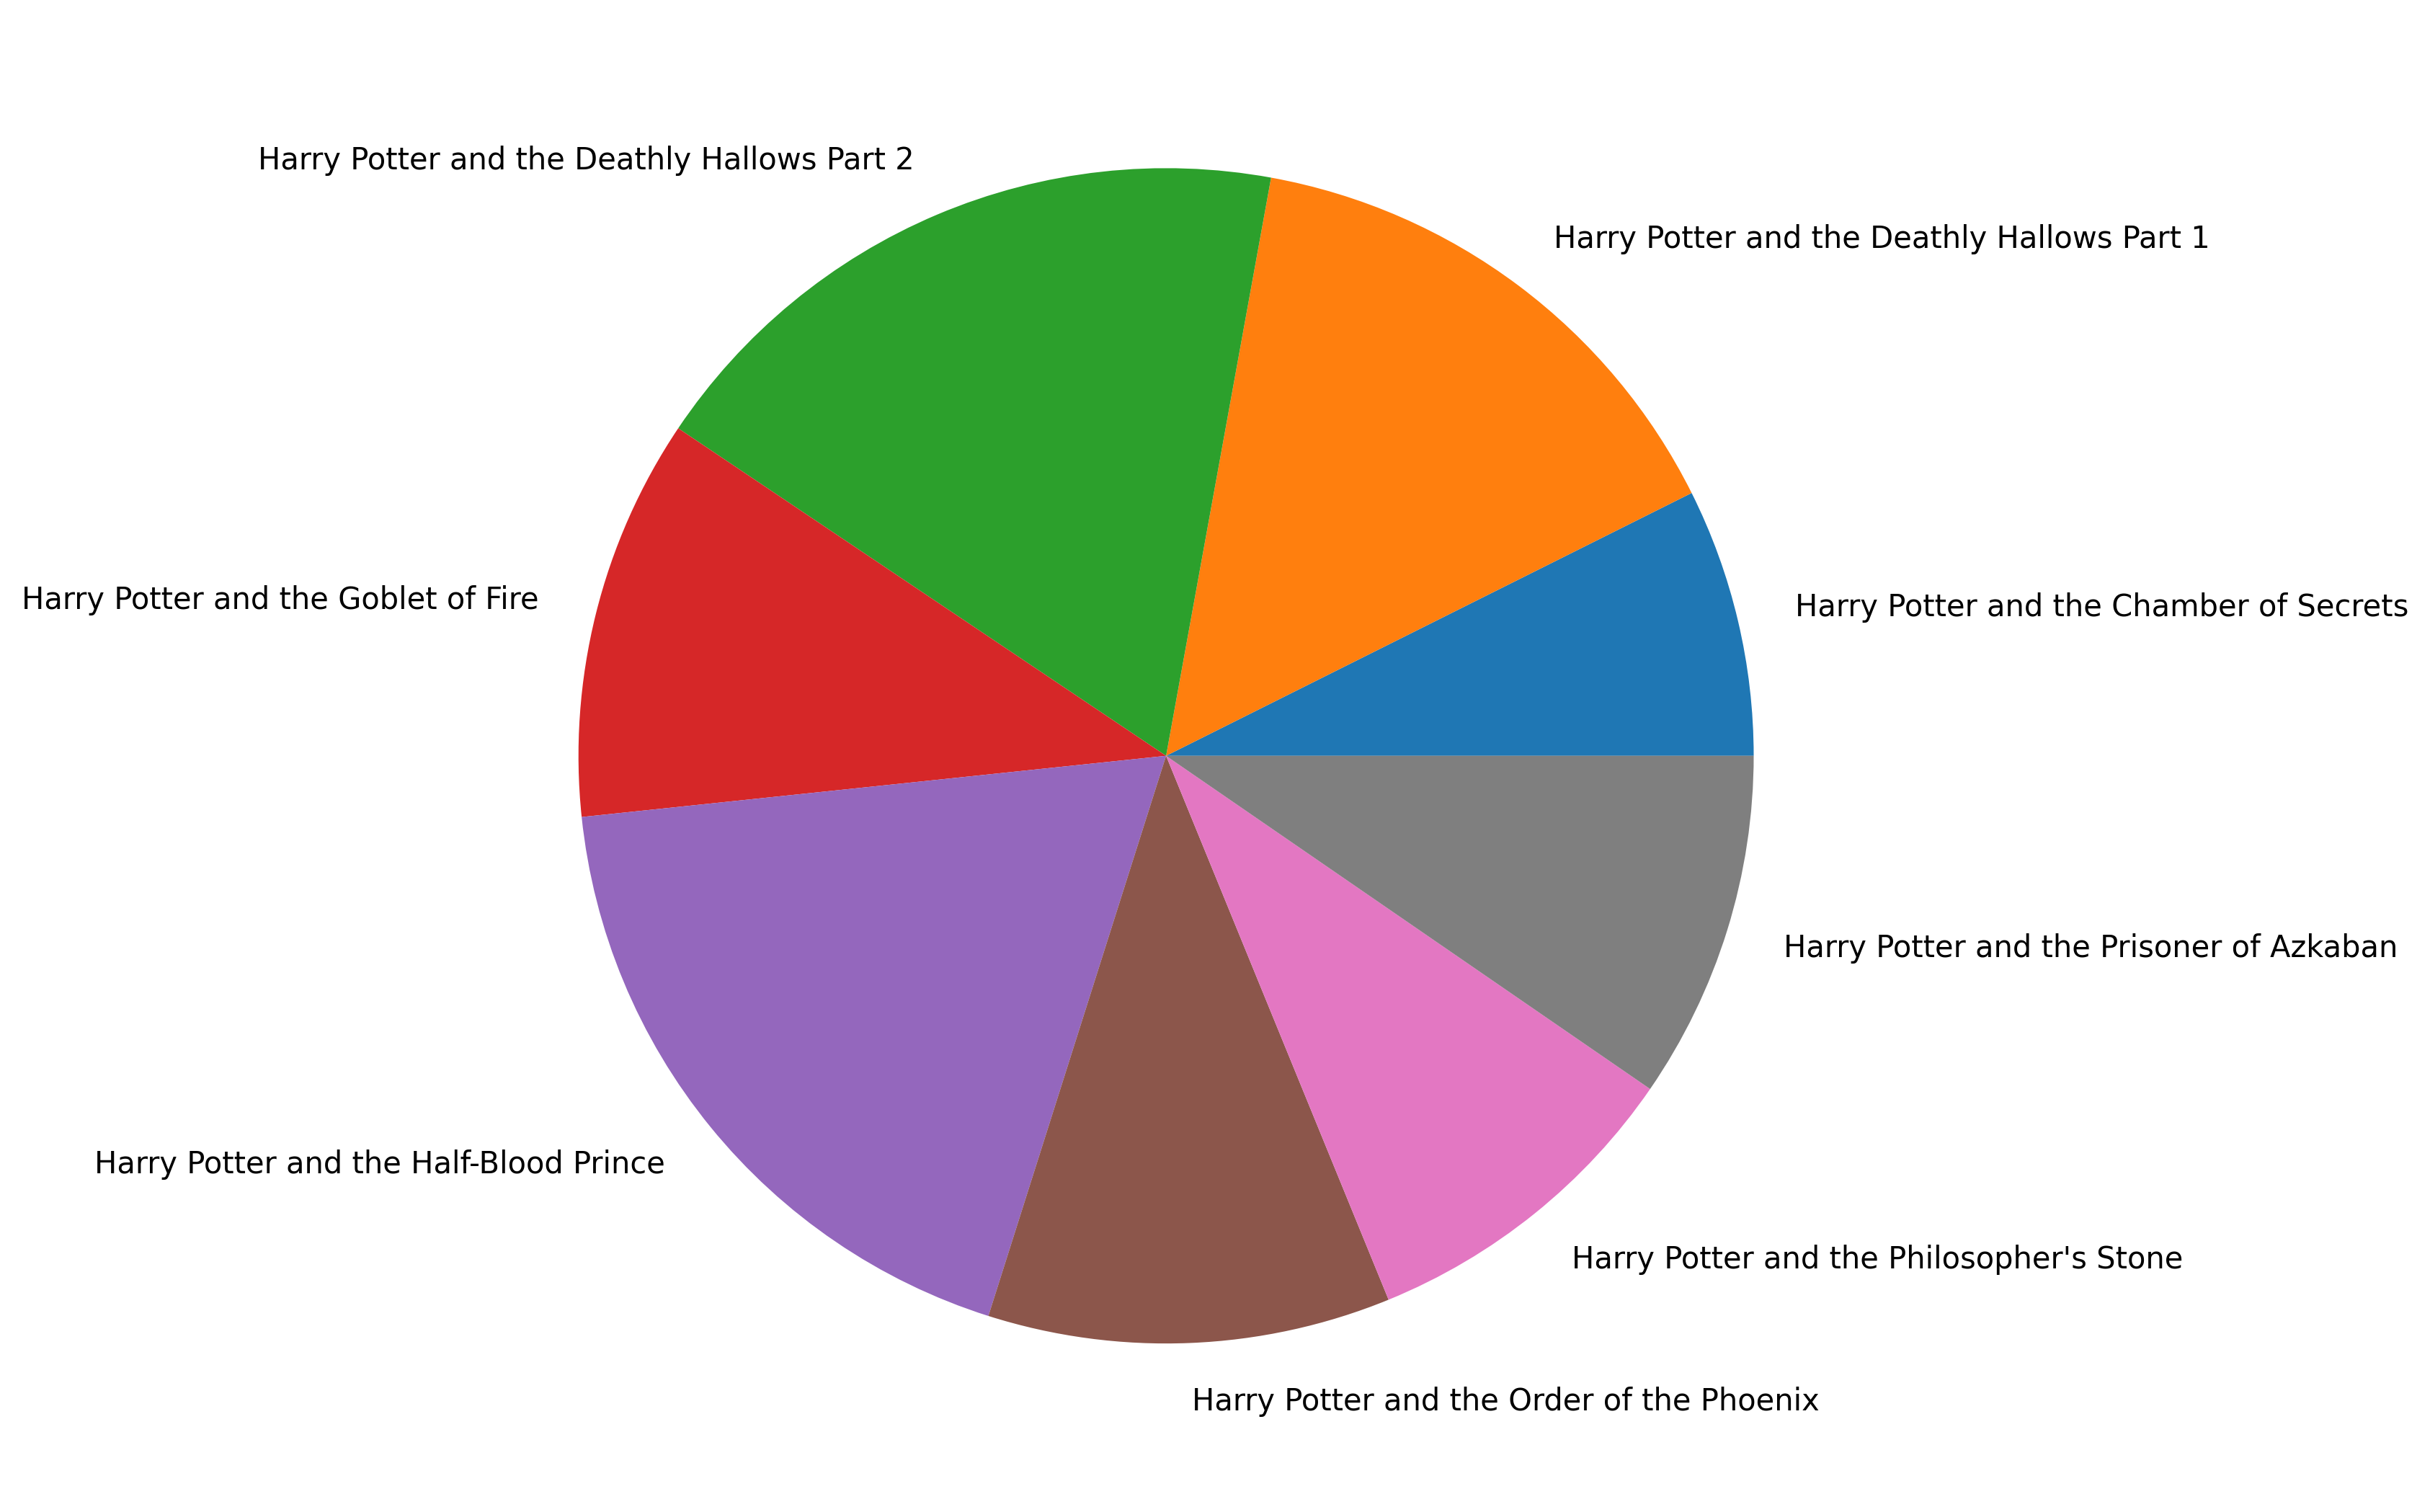

In [36]:
fig, ax = plt.subplots(figsize = (16, 9), dpi = 300)

# на первом месте – числа
# в labels – подписи

ax.pie(vals, labels = labs);

Добавим подписи с процентами, дописав аргумент `autopct` (от *auto percentage*, автоматический расчёт процентов):

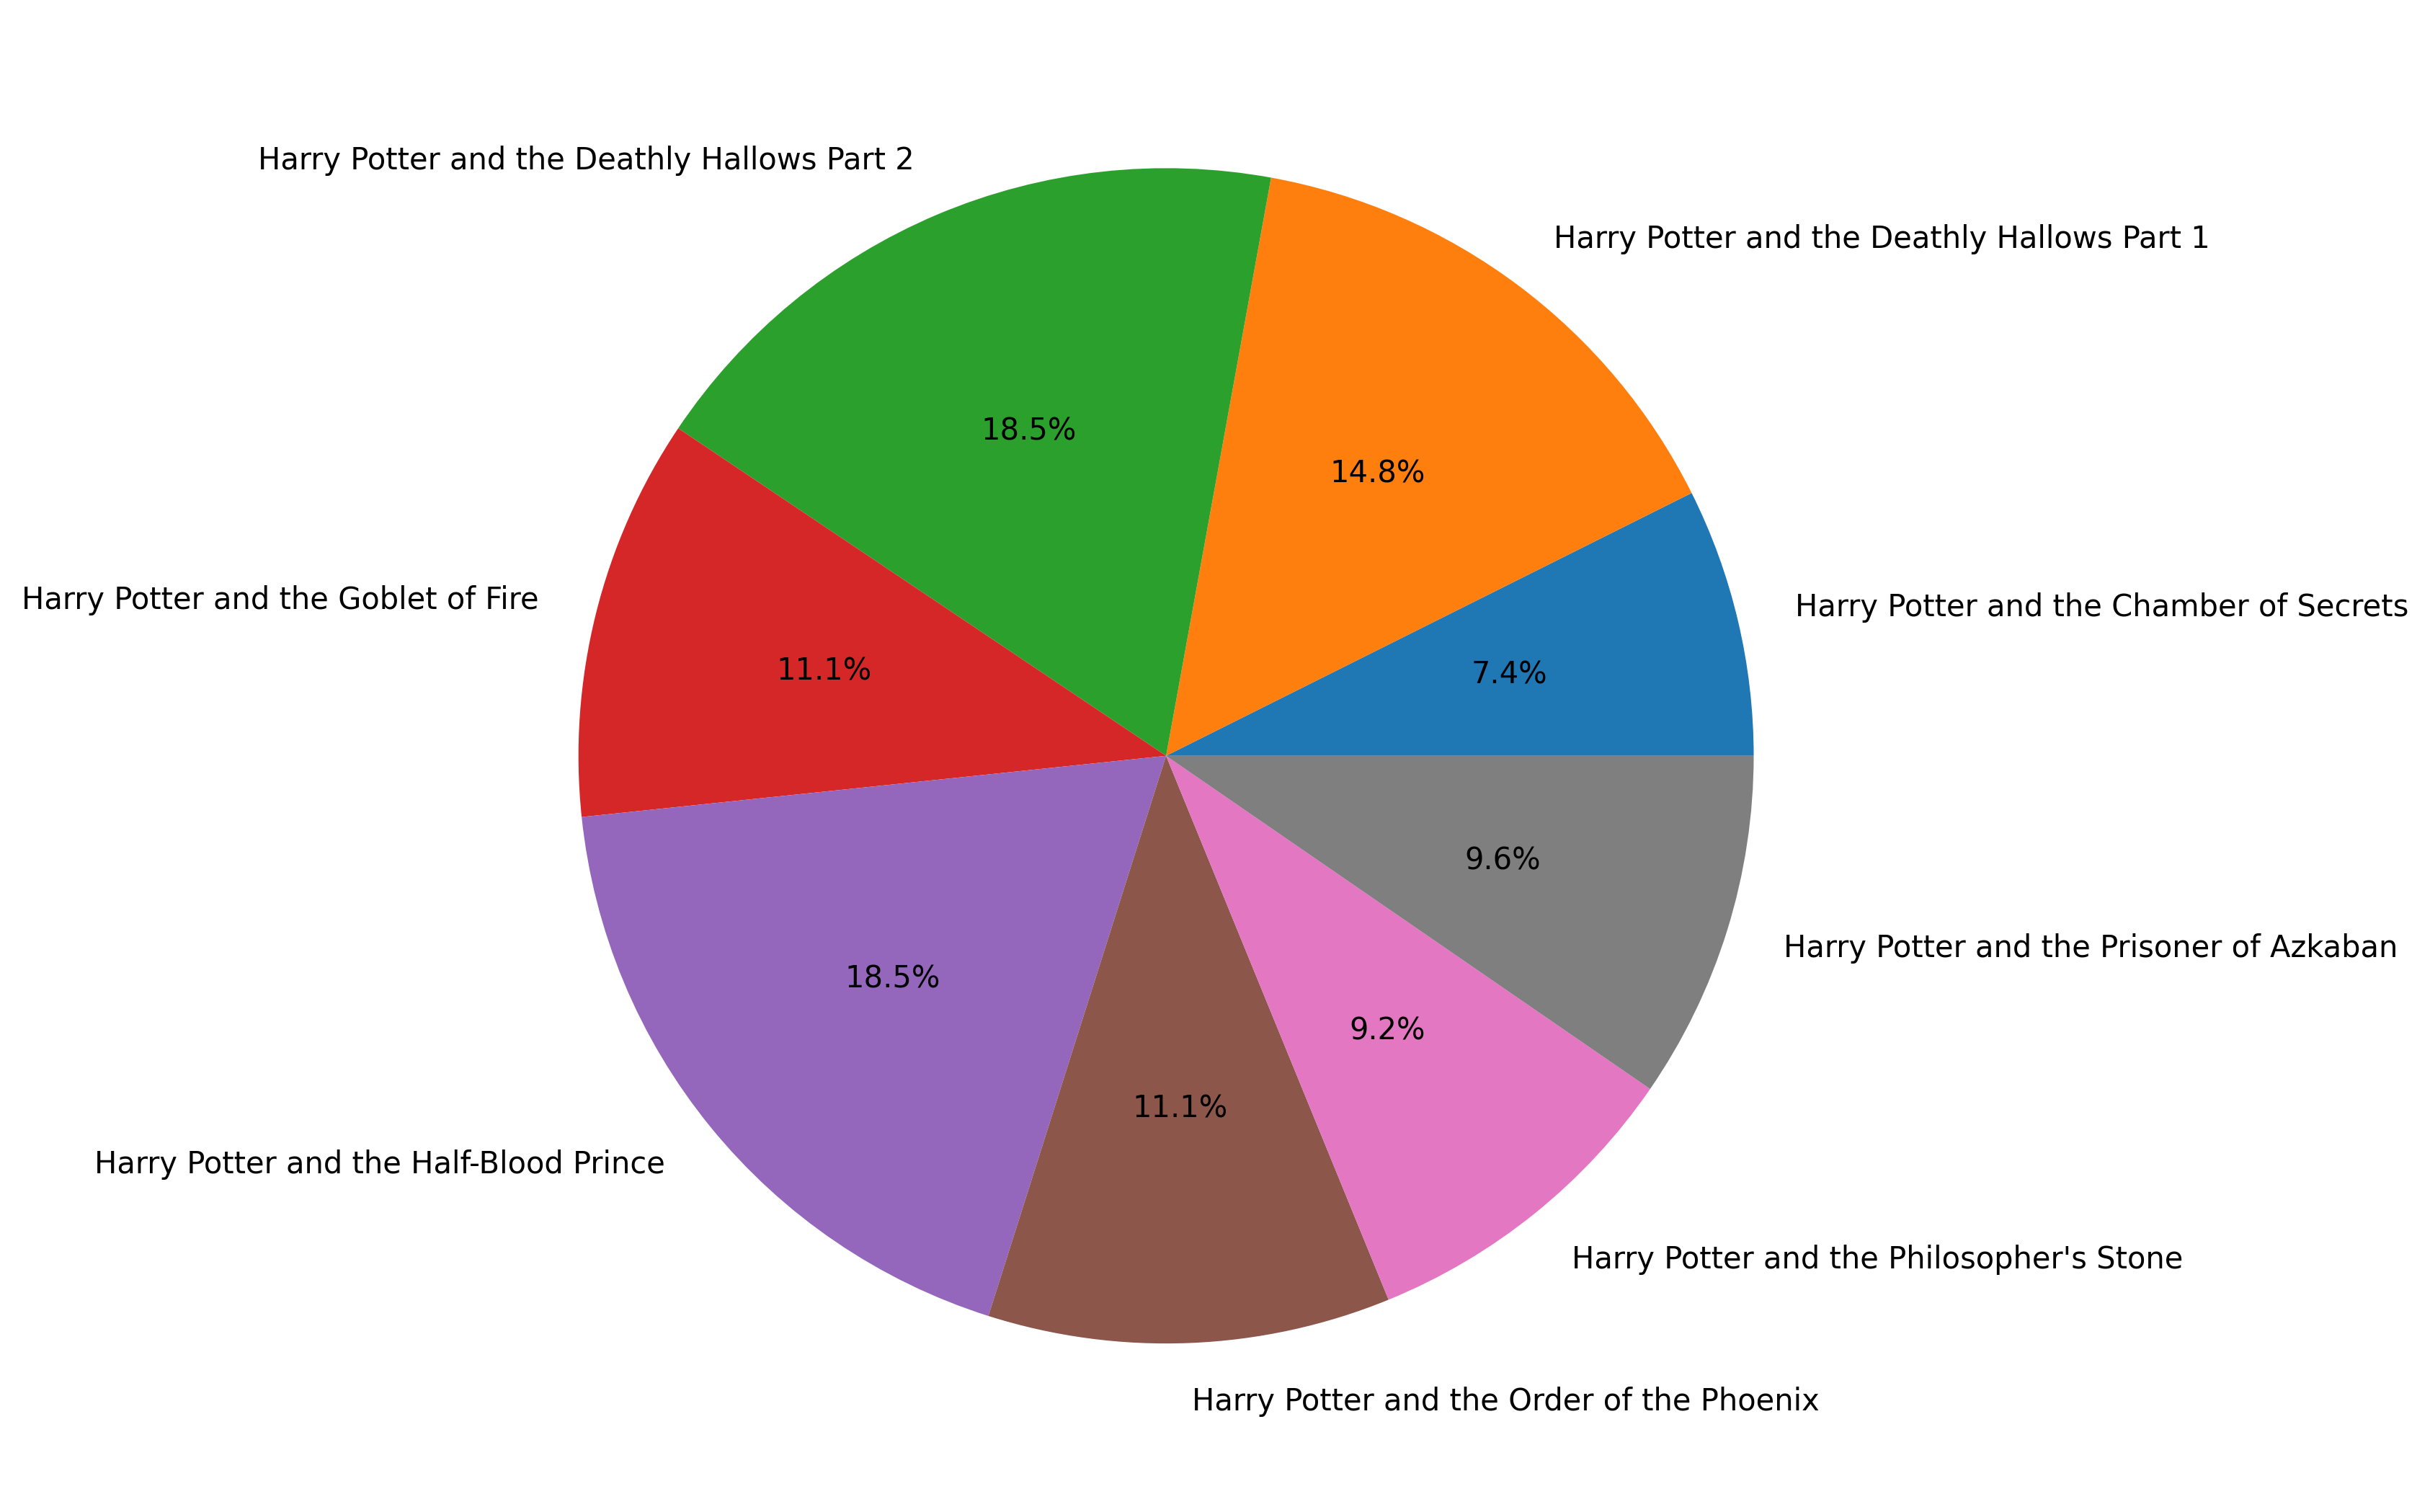

In [37]:
fig, ax = plt.subplots(figsize = (16, 9), dpi = 300)

# проценты записываются в виде строк,
# в строки подставляются числа типа float 
# с одним знаком после точки – отсюда формат %.1f
# %% показывает, что мы хотим добавить "%" как символ

ax.pie(vals, labels = labs, autopct = "%.1f%%");

График далёк от идеала, но чтобы его немного улучшить, перейдём от круговой диаграммы (*pie chart*) к кольцевой (*donut chart* или *ring chart*). В `matplotlib` нет специальной функции для такого типа визуализации, поэтому придётся пойти на хитрость – «наклеить» на полученную круговую диаграмму белый круг меньшего радиуса.

Все видимые внутри осей графика объекты в `matplotlib` относятся к классу `Artist`. Так, прямоугольники для столбцов в столбиковой диаграмме  – объекты типа `Rectangle` внутри класса `Artist`, а сектора в круговой диаграмме – объекты типа `Wedge` внутри класса `Artist`. Мы можем создать новый объект типа `Circle`, а затем добавить его к уже отрисованному изображению в `fig`:

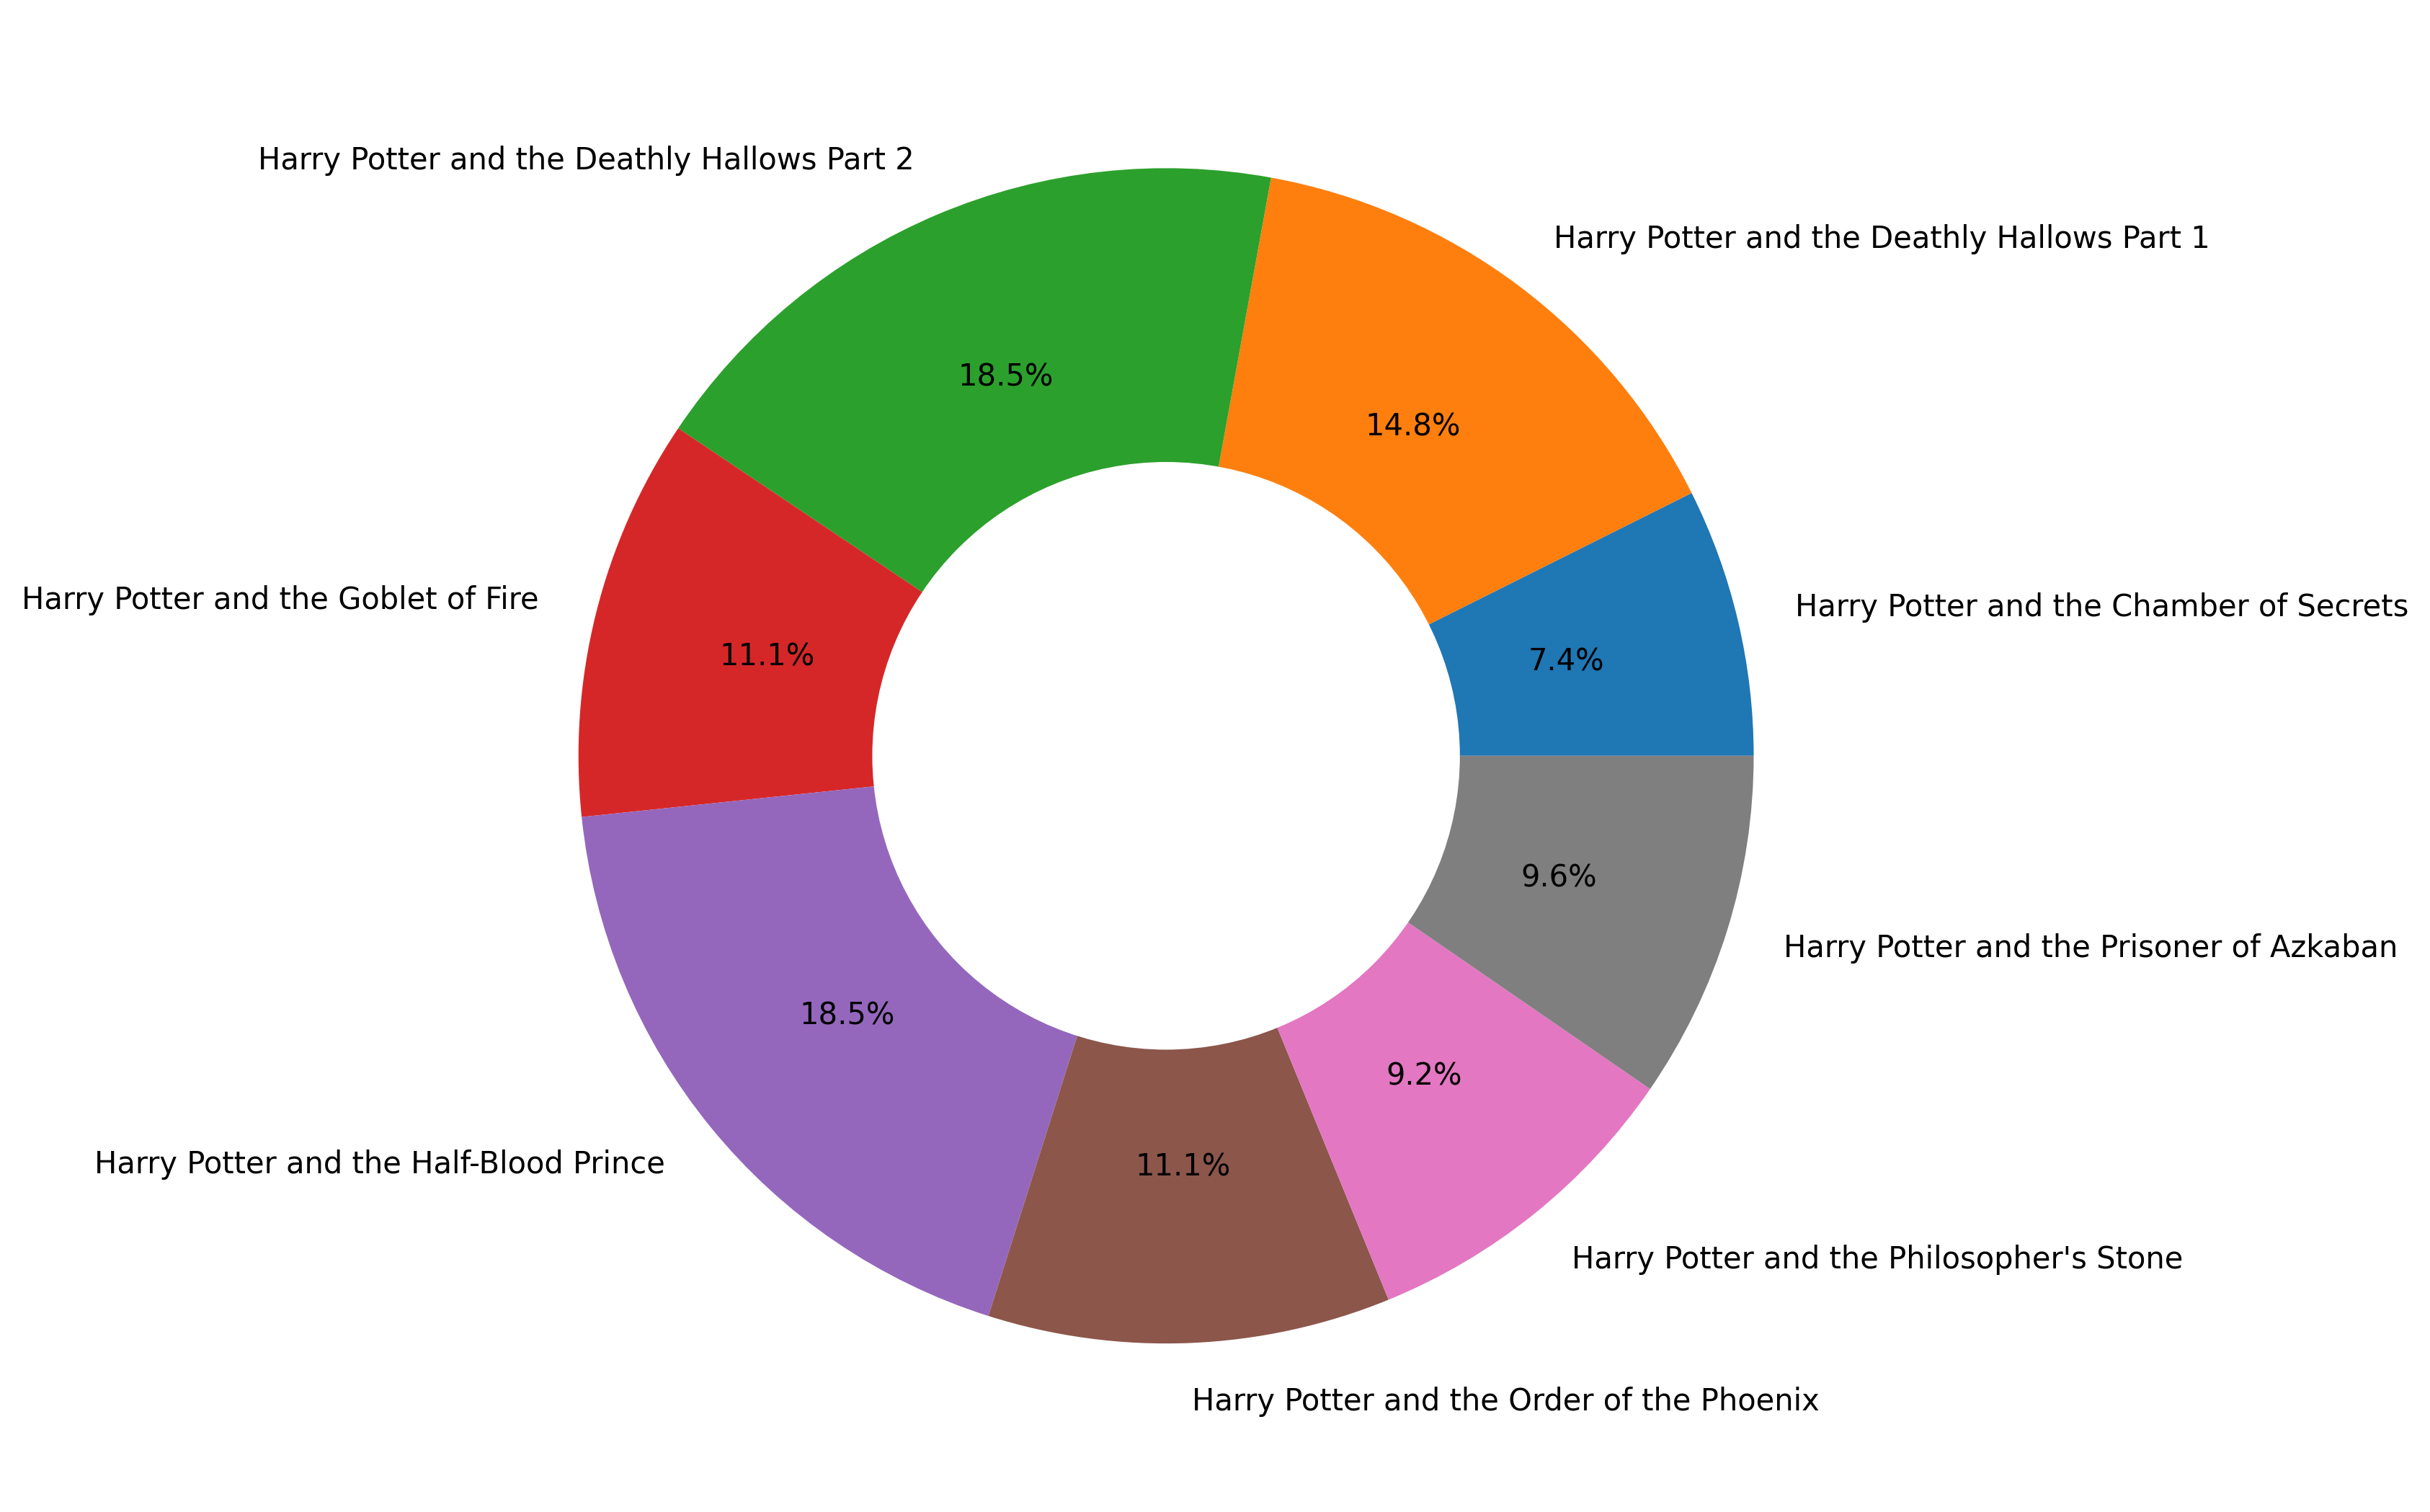

In [38]:
fig, ax = plt.subplots(figsize = (16, 9), dpi = 300)

# чтобы подписи с процентами смотрелись хорошо, 
# отодвинем их от центра подальше (pctdistance = 0.7)

ax.pie(vals, labels = labs, 
       autopct = "%.1f%%", 
       pctdistance = 0.7);

# круг белого цвета (fc = face color)
# с центром в точке (0, 0) и радиусом 0.5

ci = plt.Circle((0, 0), 0.5, fc = "white")

# добавляем ci к fig
# gca() – от get current axes

fig.gca().add_artist(ci);

# выгружаем в файл

fig.savefig("hp_pie.png")

Такой график смотрится получше. Конечно, его ещё нужно доработать, как минимум – вынести названия фильмов в легенду или сделать подписи более компактными, но это вынесем в материалы для желающих, поскольку для продвинутых настроек диаграмму придётся разбирать на части (сектора, подписи с процентами, подписи с названиями фильмов) и работать с каждой частью отдельно.